# Gene expression analysis

In [1]:
# Load packages
suppressPackageStartupMessages({
    library(ggplot2)
    library(biomaRt)
    library(BiocParallel)
    library(Matrix)
    library(matrixStats)
    library(scater)
    library(reshape2)
    library(knitr)
    library(scran)
    library(SingleCellExperiment)
    library(Seurat)
    library(data.table)
    library(dplyr)
    library(gridExtra)
    library(viridis)
    
    library(edgeR)
    library(ggrastr)
    library(ggrepel)
})
    ncores = 4
    mcparam = MulticoreParam(workers = ncores)
    register(mcparam)
    BPPARAM = SerialParam()

options(repr.plot.width=15, repr.plot.height=8)

Warning message:
“package ‘knitr’ was built under R version 4.1.2”
Warning message:
“package ‘Seurat’ was built under R version 4.1.2”


In [2]:
main = "/rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/"
mapping_dir = paste0(main, '07_atlas_mapping/')
out_dir = paste0(main, '09_gene_expression_analysis/')
plot_dir = paste0(main, '09_gene_expression_analysis/plots/')
dir.create(out_dir, showWarnings = FALSE)
dir.create(plot_dir, showWarnings = FALSE)


source(paste0(main, "mapping_functions.R"))

In [3]:
umap_theme =  theme(text = element_text(size = 30),
                axis.text.y   = element_blank(),
                axis.text.x   = element_blank(),
                axis.title.y  = element_blank(),
                axis.title.x  = element_blank(),
                axis.ticks = element_blank(),
                legend.position = "none",
                panel.background = element_blank(),
                panel.grid.major = element_blank(), 
                panel.grid.minor = element_blank(),
                panel.border = element_rect(colour = "black", fill=NA, size=1))

In [4]:
load_data(remove_doublets = TRUE, remove_stripped = TRUE)
meta = read.csv(paste0(mapping_dir, 'meta_complete.csv'))

In [5]:
sce
nrow(meta)

class: SingleCellExperiment 
dim: 29453 27776 
metadata(0):
assays(2): counts logcounts
rownames(29453): ENSMUSG00000051951 ENSMUSG00000089699 ...
  ENSMUSG00000095742 tomato-td
rowData names(0):
colnames(27776): cell_1 cell_2 ... cell_30169 cell_30171
colData names(1): sizeFactor
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

[1] 27776

In [6]:
meta$umap_1 = as.numeric(meta$umap_1)
meta$umap_2 = as.numeric(meta$umap_2)

In [7]:
genenames = fread("/rds/project/rds-SDzz0CATGms/users/bt392/gene_names.csv") %>% 
            setnames(c('ensembl_gene_id','external_gene_name'), c('gene', 'gene_name'))
genenames = genenames[genenames$gene %in% rownames(sce)]
genenames = merge(genenames, as.data.frame(rownames(sce)), by.x='gene', by.y='rownames(sce)', all.y=TRUE)
genenames$gene_name[genenames$gene_name==''] = NA
genenames[is.na(genenames$gene_name),] = genenames$gene[is.na(genenames$gene_name)]
genenames = genenames[order(match(genenames$gene, rownames(sce)))]
rownames(sce) = genenames$gene_name

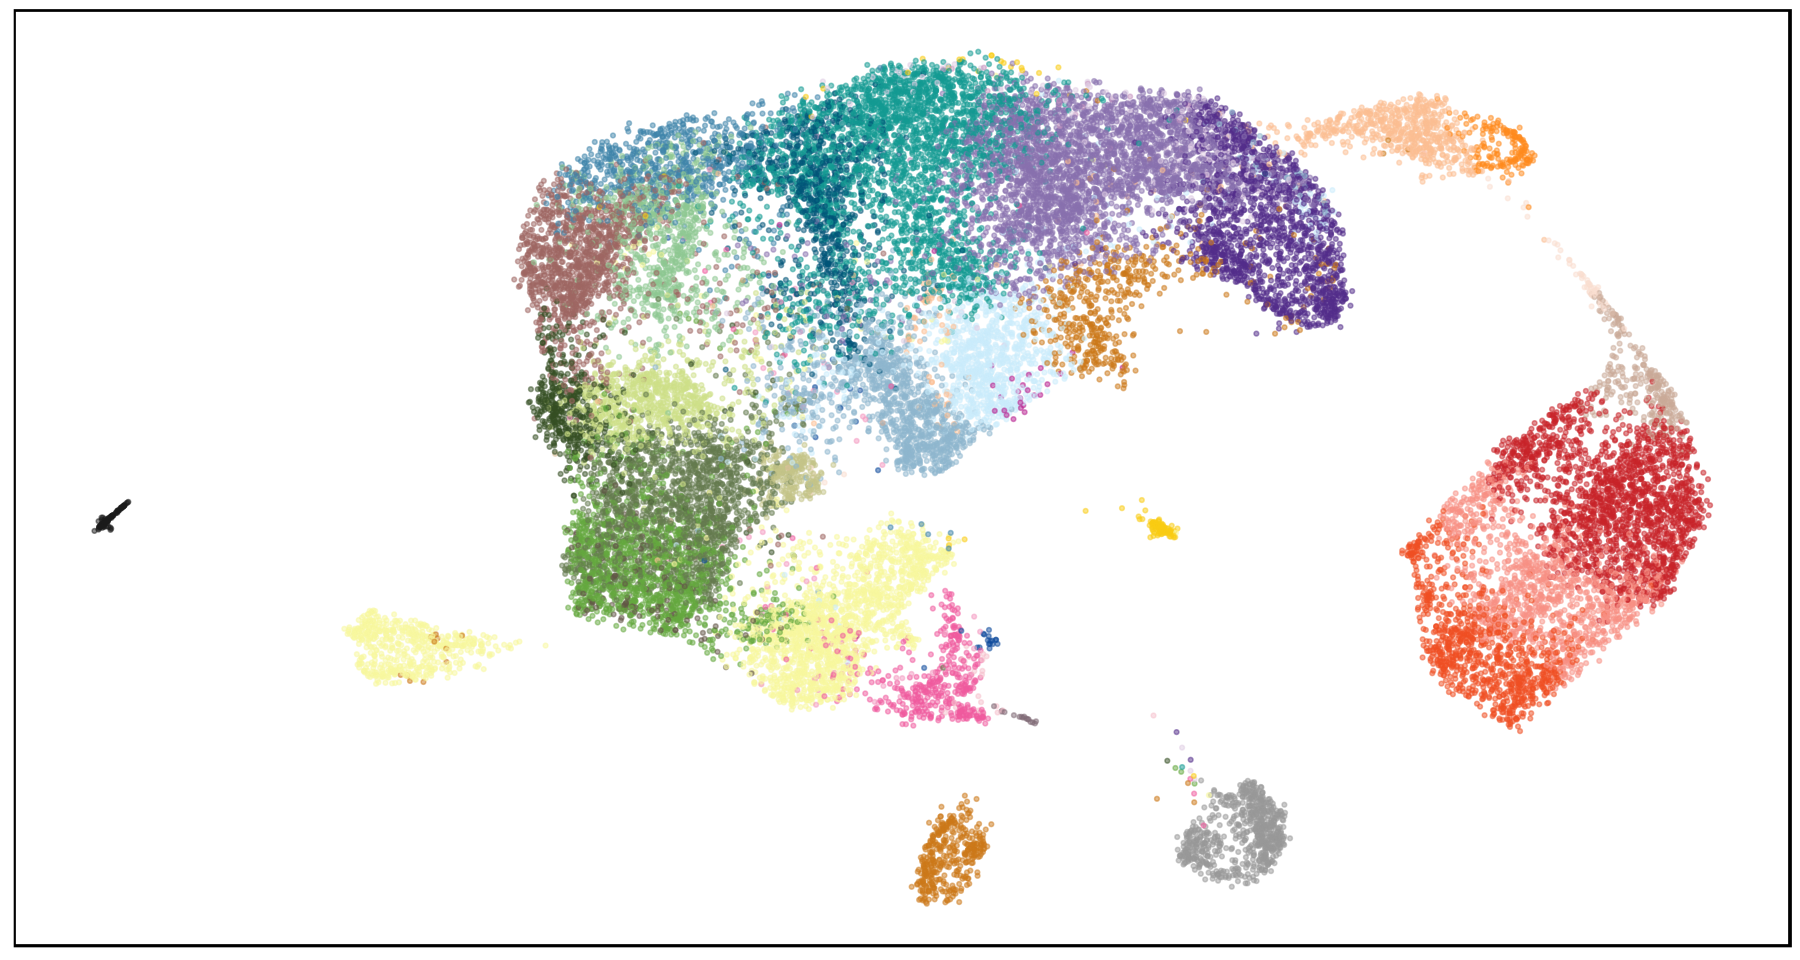

In [18]:
ggplot(meta, aes(umap_1, umap_2, col=celltype.mapped)) + 
        geom_point(size = 0.7, alpha = 0.5) + 
    scale_colour_manual(values = celltype_colours,  name = "celltype") +
        umap_theme

In [19]:
sce

class: SingleCellExperiment 
dim: 29453 27776 
metadata(0):
assays(2): counts logcounts
rownames(29453): Xkr4 Gm1992 ... ENSMUSG00000095742 tomato-td
rowData names(0):
colnames(27776): cell_1 cell_2 ... cell_30169 cell_30171
colData names(1): sizeFactor
reducedDimNames(0):
altExpNames(0):

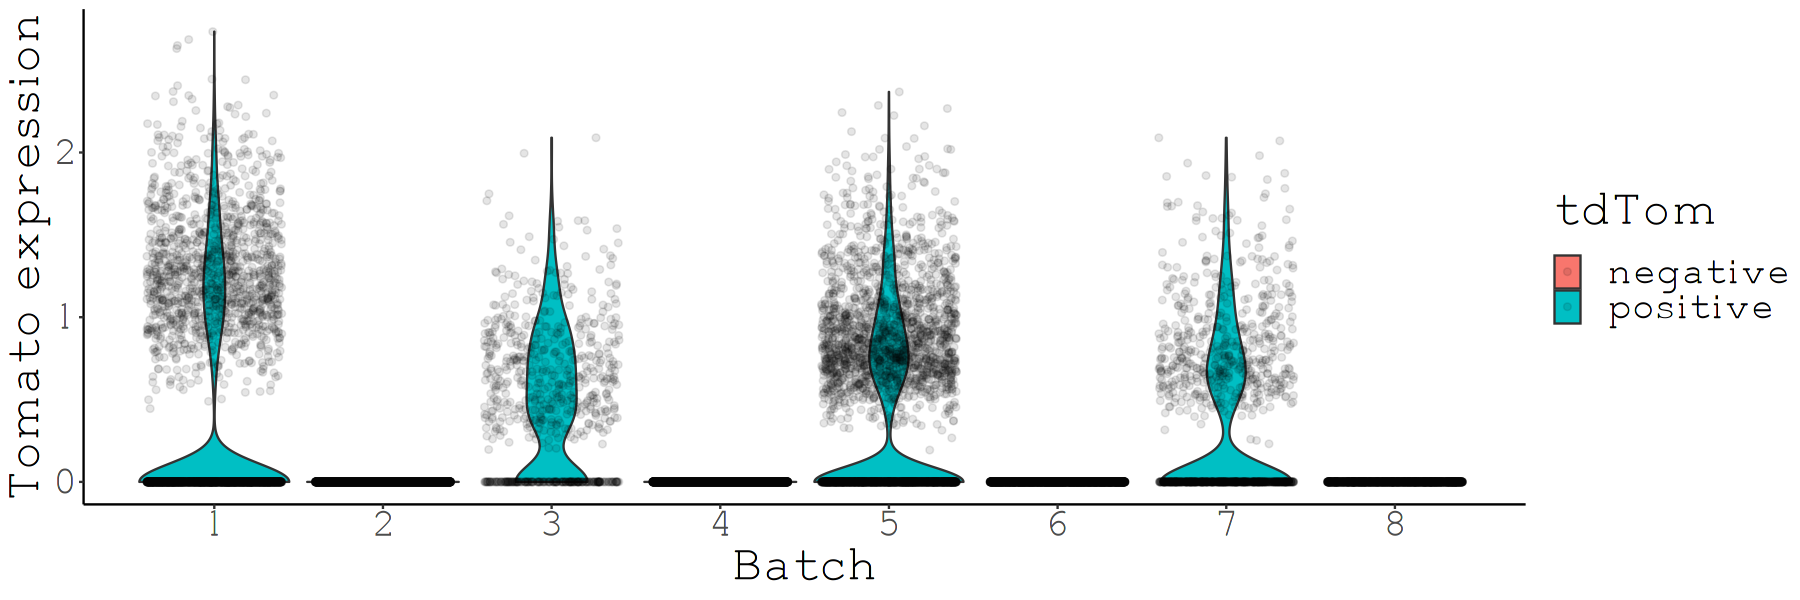

In [20]:
p6 = ggplot(meta, aes(as.factor(batch), as.vector(logcounts(sce[nrow(sce),])), group=batch, fill=tdTom)) + 
    geom_violin() +
    geom_point(position = position_jitterdodge(jitter.width =0.8), alpha=0.1) +
    theme_classic() + 
    theme(text = element_text(size=30)) + 
    xlab('Batch') + ylab('Tomato expression')
options(repr.plot.width=15, repr.plot.height=5)
p6
options(repr.plot.width=15, repr.plot.height=8)

#### Interrogation of specific gene sets

In [11]:
WT = meta[meta$tdTom=='negative',]
KO = meta[meta$tdTom!='negative',]

ct_nr = reshape2::dcast(as.data.frame(table(meta$celltype.mapped, meta$tdTom)), Var1 ~ Var2)
keep = ct_nr[ct_nr$negative>10 & ct_nr$positive>10,]$Var1

meta_seurat = meta[meta$celltype.mapped %in% keep,]
rownames(meta_seurat) = meta_seurat$cell
seurat = CreateSeuratObject(counts(sce[,meta_seurat$cell]), project = "SeuratProject", assay = "RNA",
  min.cells = 0, min.features = 0, meta =meta_seurat)

seurat[['logcounts']] = CreateAssayObject(counts = logcounts(sce[,meta_seurat$cell]))
DefaultAssay(seurat) = 'logcounts'

Using Freq as value column: use value.var to override.

Warning message:
“Non-unique features (rownames) present in the input matrix, making unique”
Warning message:
“Non-unique features (rownames) present in the input matrix, making unique”


In [12]:
plot_gene = function(x){

    gene = logcounts(sce[x,])/max(logcounts(sce[x,]))
      
    p1 = ggplot(WT, aes(umapX.mapped, umapY.mapped, col=as.vector(gene[,cell]))) + 
        geom_point(data=KO, aes(umapX.mapped, umapY.mapped), col='grey90', size = 0.7) + 
        geom_point(size = 0.7, alpha = 0.5) + 
        scale_color_viridis(option='magma') + 
        labs(title = paste0(x), 
             subtitle = 'WT') +
        umap_theme + theme(plot.margin = unit(c(1, 0.5, -4, 1), "lines"))
    p2 = ggplot(KO, aes(umapX.mapped, umapY.mapped, col=as.vector(gene[,cell]))) + 
        geom_point(data=WT, aes(umapX.mapped, umapY.mapped), col='grey90', size = 0.7) + 
        geom_point(size = 0.7, alpha = 0.5) + 
        scale_color_viridis(option='magma') + 
        labs(title = paste0(''), 
             subtitle = 'KO') +
        umap_theme + theme(plot.margin = unit(c(1, 1, -4, 0.5), "lines"))
    
    legend_plot = ggplot(meta, aes(umapX.mapped, umapY.mapped, col=as.vector(logcounts(sce[x,])))) + 
        geom_point(size = 0.7, alpha = 0.5) + 
        scale_color_viridis(option='magma', name='Expr') + 
        labs(title = paste0(''), 
             subtitle = 'KO') +
        theme_bw()+ theme(legend.position = c(0.2, 0.3), 
                          text = element_text(color='black'))
    p1_legend = cowplot::get_legend(legend_plot)
    
df = data.frame('cell'=meta$cell, 'celltype' = meta$celltype.mapped, 'tdTom'= meta$tdTom, 'gene'= as.vector(logcounts(sce[x,])))
df = df %>% group_by(celltype, tdTom) %>% summarize('mean' = mean(gene))#/max(gene))

    p3=ggplot(df[df$celltype %in% keep,], aes(celltype, tdTom, fill=mean)) +       
        scale_fill_viridis(option='magma', name='', end = max(df$mean)/max(as.vector(logcounts(sce[x,])))) + 
        scale_y_discrete(labels=c('WT', 'KO'))+
        geom_tile(colour="white",size=0.2) +
        theme_void() +
        theme(axis.title.x=element_blank(),
              axis.title.y=element_blank(), 
              text= element_text(size = 20, color='black'), 
            #  axis.text.x=element_text(angle = -90, vjust = 0, hjust=0, size = 14, color='black'),
              axis.text.x=element_blank(),
              axis.text.y=element_text(angle=90), 
              legend.position='none',
              aspect.ratio = 0.15, plot.margin = unit(c(-5, 1, -5, 1), "lines"))

    p4 = VlnPlot(seurat,x,split.by='tdTom', group.by='celltype.mapped', pt.size=0, split.plot = TRUE) + 
                scale_fill_manual(values = c('positive' = 'red', 'negative' = 'black')) +
        ylab('')+
        theme(axis.title.x=element_blank(),
              axis.title.y=element_text(size=0), 
              text= element_text(size = 30, color='black'), 
              axis.text.x=element_text(angle = -90, vjust = 0, hjust=0, size = 13, color='black'),
             # axis.text.y=element_text(angle=90), 
              legend.position='none',
              aspect.ratio = 0.2,
              plot.title = element_blank(), plot.margin = unit(c(-5, 1, -3, 1), "lines"))
    
    #grid.arrange(arrangeGrob(p1, p2, ncol=2), p3, p4, ncol=1)
    grid.arrange(arrangeGrob(p1, p2, p1_legend, ncol=3, widths=c(1,1,0.1)), p3, p4, ncol=1)

}


In [97]:
# for mai-linh
genes = c('Tgfbr1','Tgfbr2','Tgfbr3', 'Bmp1', 'Bmp2', 'Bmp3', 'Bmp4', 'Bmp5', 'Bmp6', 'Bmp7', 'Acvr1', 'Acvr1b', 'Acvr1c', 'Mixl1', 'Eomes', 'T')
genes = genes[genes %in% rownames(sce)]

In [98]:
for(i in 1:length(genes)){
png(paste0(plot_dir, 'gene_', genes[i], '.png'), width=2400, height = 2700, res = 300)
    suppressMessages(plot_gene(genes[i]))
dev.off()
    }

##### For Luke


In [13]:
expressed_genes = rownames(sce[Matrix::rowSums(counts(sce)) > 500,])

In [14]:
Chip = read.csv2("/rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/Genelist/Eomes_ChIP_Seq_GREAT_4.0.4_Default_Peak_Gene_Associations.txt", skip=1, sep='\t', header=FALSE)

In [15]:
genes = Chip$V1
genes = genes[genes %in% expressed_genes]

In [16]:
for(i in 1:length(genes)){
png(paste0(plot_dir, 'Chip/',genes[i], '.png'), width=2400, height = 2700, res = 300)
    suppressMessages(plot_gene(genes[i]))
dev.off()
    }

In [ ]:
# PdgfRa negative

In [17]:
pos = read.csv("/rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/Genelist/Flk1pos_PdgfRapos_day_4_EB_eo_ko.csv")

In [18]:
pos_up = pos[pos$Log2_Fold_Change > 1, ]

In [19]:
genes = pos_up$Probe
genes = genes[genes %in% expressed_genes]
genes = head(genes, 10)

In [20]:
for(i in 1:length(genes)){
png(paste0(plot_dir, '/pdgfra_pos/up/',i,'_', genes[i], '.png'), width=2400, height = 2700, res = 300)
    suppressMessages(plot_gene(genes[i]))
dev.off()
    }

In [21]:
pos_down = pos[pos$Log2_Fold_Change < -1, ]

In [22]:
genes = pos_down$Probe
genes = genes[genes %in% expressed_genes]
genes = tail(genes, 10)

In [23]:
for(i in 1:length(genes)){
png(paste0(plot_dir, '/pdgfra_pos/down/',i,'_', genes[i], '.png'), width=2400, height = 2700, res = 300)
    suppressMessages(plot_gene(genes[i]))
dev.off()
    }

In [24]:
# PdgfRa negative

In [25]:
neg = read.csv("/rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/Genelist/Flk1pos_PdgfRaneg_day_4_EB_eo_ko.csv")

In [26]:
neg_up = neg[neg$Log2_Fold_Change > 1, ]

In [27]:
genes = neg_up$Probe
genes = genes[genes %in% expressed_genes]
genes = head(genes, 10)

In [28]:
for(i in 1:length(genes)){
png(paste0(plot_dir, '/pdgfra_neg/up/',i,'_', genes[i], '.png'), width=2400, height = 2700, res = 300)
    suppressMessages(plot_gene(genes[i]))
dev.off()
    }

In [29]:
neg_down = neg[neg$Log2_Fold_Change < -1, ]

In [30]:
genes = neg_down$Probe
genes = genes[genes %in% expressed_genes]
genes = tail(genes, 10)

In [31]:
for(i in 1:length(genes)){
png(paste0(plot_dir, '/pdgfra_neg/down/',i,'_', genes[i], '.png'), width=2400, height = 2700, res = 300)
    suppressMessages(plot_gene(genes[i]))
dev.off()
    }

#### Plot gene scores

In [ ]:

plot_gene_score = function(x, name){
    score = Matrix::colMeans(logcounts(sce[x,]))/max(Matrix::colMeans(logcounts(sce[x,])))

    p1 = ggplot(WT, aes(umapX.mapped, umapY.mapped, col=as.vector(score[cell]))) + 
            geom_point(data=KO, aes(umapX.mapped, umapY.mapped), col='grey90', size = 0.7) + 
            geom_point(size = 0.7, alpha = 0.5) + 
            scale_color_viridis(option='magma', begin=0, end = 0.5) + 
            labs(title = paste0(name, ' score'), 
                subtitle = 'WT') +
            umap_theme
    p2 = ggplot(KO, aes(umapX.mapped, umapY.mapped, col=as.vector(score[cell])))  + 
        geom_point(data=WT, aes(umapX.mapped, umapY.mapped), col='grey90', size = 0.7) + 
        geom_point(size = 0.7, alpha = 0.5) + 
        scale_color_viridis(option='magma') + 
        labs(title = paste0(''), 
             subtitle = 'KO') +
        umap_theme

df = data.frame('cell'=meta$cell, 'celltype' = meta$celltype.mapped, 'tdTom'= meta$tdTom, 'gene'= as.vector(Matrix::colMeans(logcounts(sce[x,]))))
df = df %>% group_by(celltype, tdTom) %>% summarize('mean' = mean(gene))#/max(gene))    

    p4 = ggplot(meta[meta$celltype.mapped %in% keep,], aes(celltype.mapped, tdTom, fill=as.vector(score)[meta$celltype.mapped %in% keep])) +       
        scale_fill_viridis(option='magma', name='') + 
        scale_y_discrete(labels=c('WT', 'KO'))+
        geom_tile(colour="white",size=0.2) +
        theme_void() +
        theme(axis.title.x=element_blank(),
              axis.title.y=element_blank(), 
              text= element_text(size = 30, color='black'), 
            #  axis.text.x=element_text(angle = -90, vjust = 0, hjust=0, size = 10, color='black'),
              axis.text.y=element_text(angle=90), 
              legend.position='none',
              aspect.ratio = 0.2)

        p3=ggplot(df[df$celltype %in% keep,], aes(celltype, tdTom, fill=mean)) +       
        scale_fill_viridis(option='magma', name='', end = max(df$mean)/max(as.vector(Matrix::colMeans(logcounts(sce[x,]))))) + 
        scale_y_discrete(labels=c('WT', 'KO'))+
        geom_tile(colour="white",size=0.2) +
        theme_void() +
        theme(axis.title.x=element_blank(),
              axis.title.y=element_blank(), 
              text= element_text(size = 20, color='black'), 
            #  axis.text.x=element_text(angle = -90, vjust = 0, hjust=0, size = 14, color='black'),
              axis.text.x=element_blank(),
              axis.text.y=element_text(angle=90), 
              legend.position='none',
              aspect.ratio = 0.2)
    
    grid.arrange(arrangeGrob(p1, p2, ncol=2), p3, p4, ncol=1)
}

In [195]:
Tgfs = c('Tgfbr1','Tgfbr2','Tgfbr3')
Bmps = c('Bmp1', 'Bmp2', 'Bmp3', 'Bmp4', 'Bmp5', 'Bmp6', 'Bmp7')
Activins = c('Acvr1', 'Acvr1b', 'Acvr1c')
Smad159 = c('Smad1', 'Smad5', 'Smad9')
Smad23 = c('Smad2', 'Smad3')

`summarise()` has grouped output by 'celltype'. You can override using the `.groups` argument.


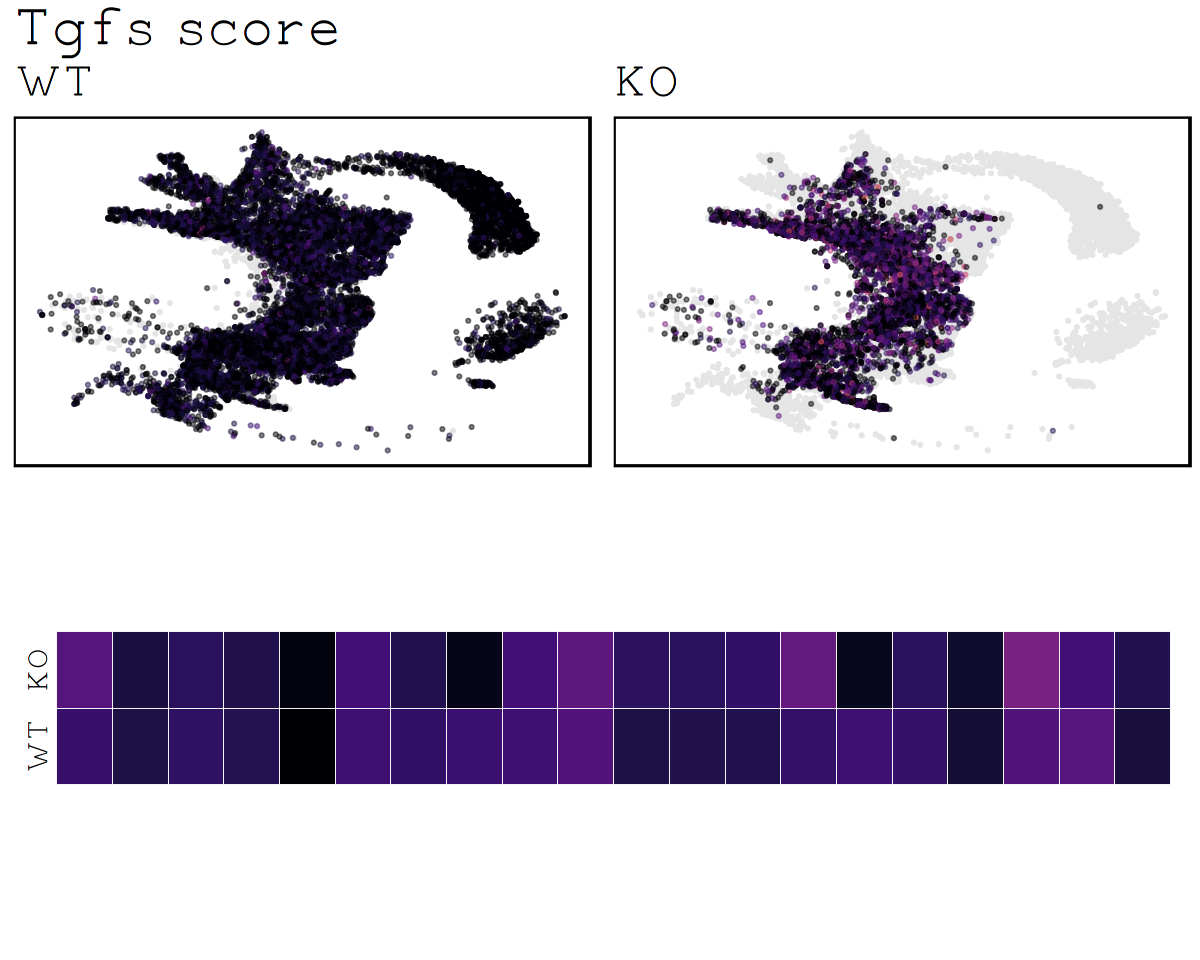

In [172]:
plot_gene_score(Smad159, 'Tgfs')

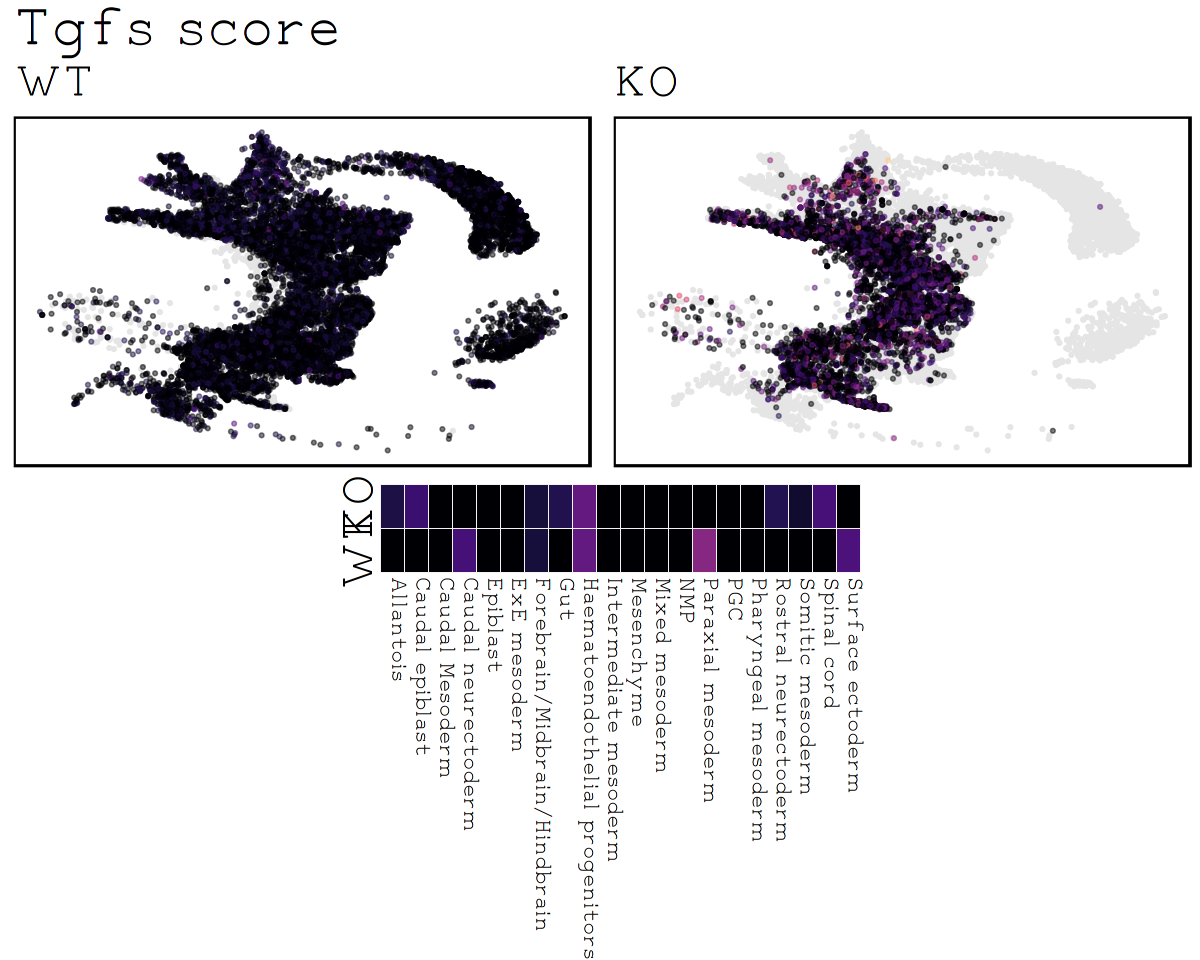

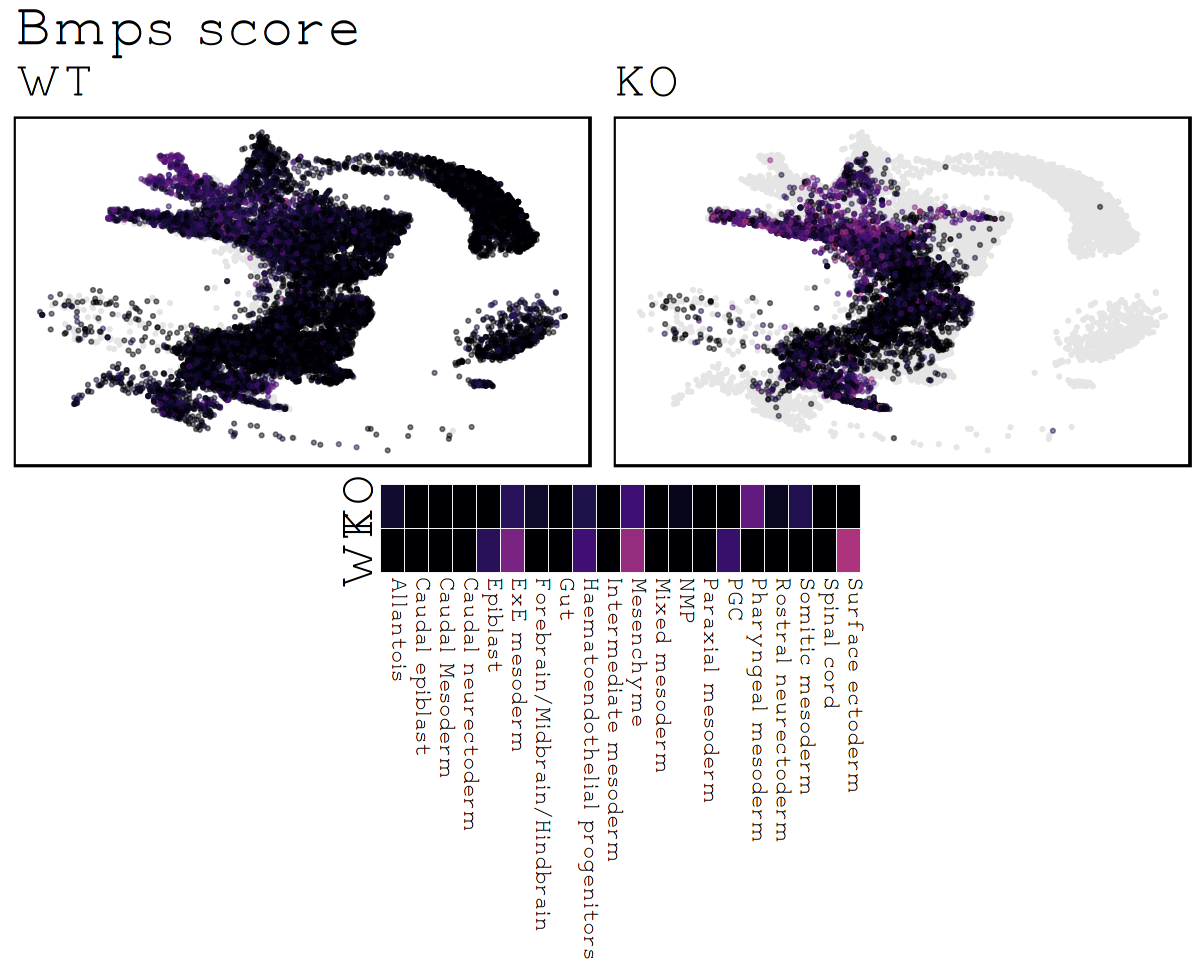

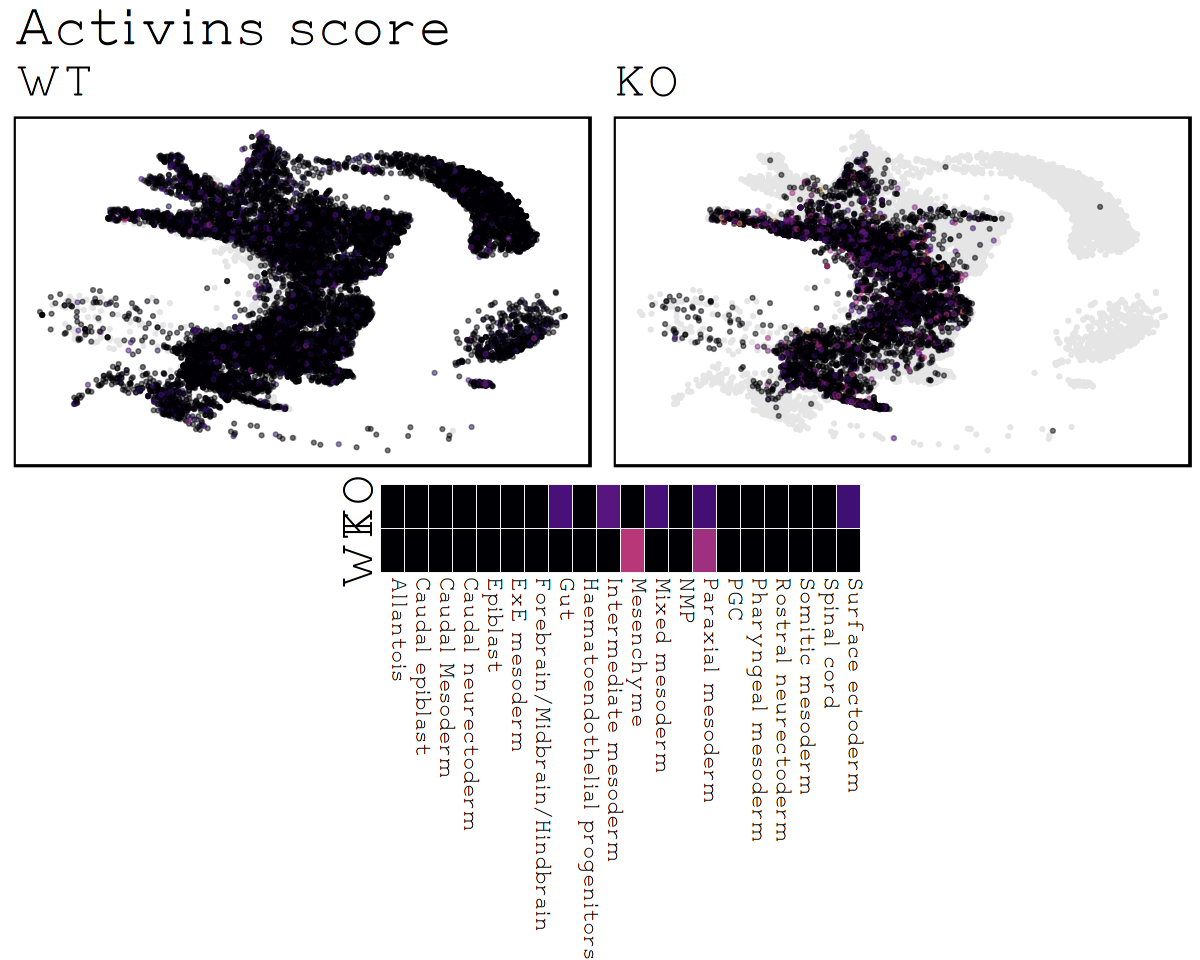

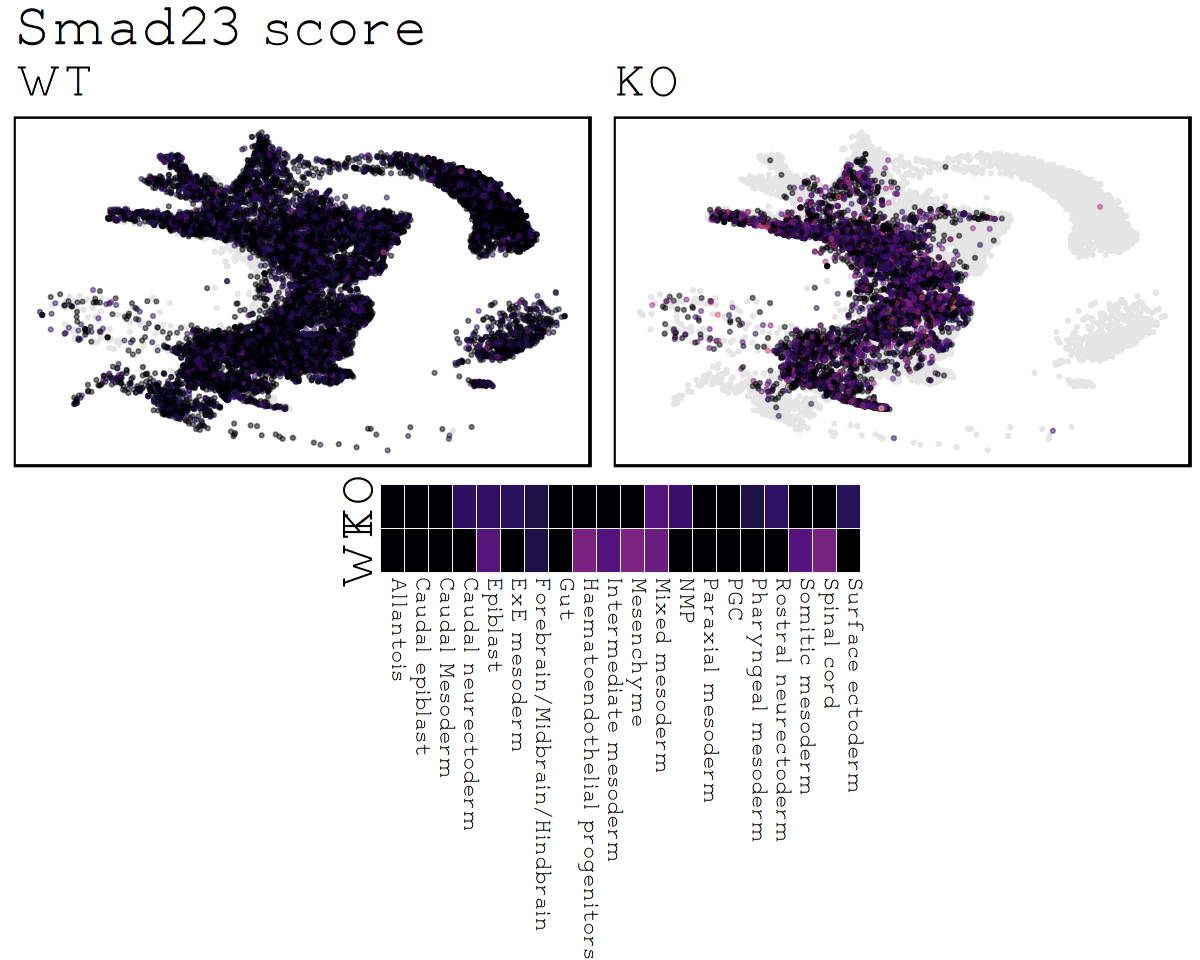

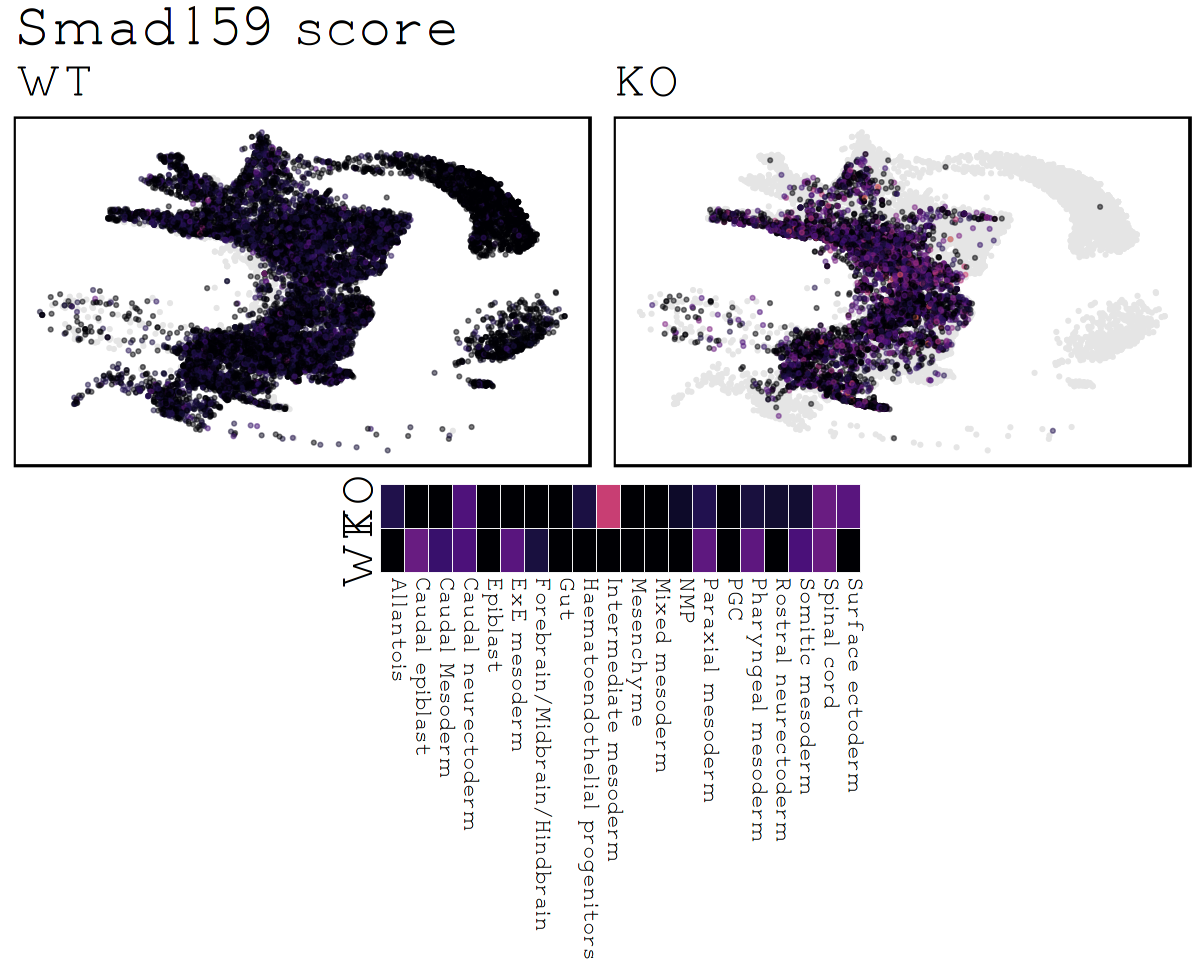

In [126]:
name = 'Tgfs'
plot = plot_gene_score(Tgfs, name)
ggsave(paste0(plot_dir, 'gene_score_', name, '.png'), plot, device='png', width=8, height = 9)
name = 'Bmps'
plot = plot_gene_score(Bmps, name)
ggsave(paste0(plot_dir, 'gene_score_', name, '.png'), plot, device='png', width=8, height = 9)
name = 'Activins'
plot = plot_gene_score(Activins, name)
ggsave(paste0(plot_dir, 'gene_score_', name, '.png'), plot, device='png', width=8, height = 9)
name = 'Smad23'
plot = plot_gene_score(Smad23, name)
ggsave(paste0(plot_dir, 'gene_score_', name, '.png'), plot, device='png', width=8, height = 9)
name = 'Smad159'
plot = plot_gene_score(Smad159, name)
ggsave(paste0(plot_dir, 'gene_score_', name, '.png'), plot, device='png', width=8, height = 9)

### EdgeR DEG analysis

#### Code ran as Rscript

In [240]:
# Function to differential expression
# - sce: SingleCellExperiment object with the column "group" in the colData
# - groups: the names of the two groups
# - min_detection_rate_per_group: minimum detection rate per group
doDiffExpr <- function(sce, groups, min_detection_rate_per_group = 0.50) {
    
  # Sanity checks
  if (!is(sce, "SingleCellExperiment")) stop("'sce' has to be an instance of SingleCellExperiment")
  stopifnot(length(groups)==2)

  # Filter genes by detection rate per group
  cdr_A <- rowMeans(logcounts(sce[,sce$group==groups[1]])>0) >= min_detection_rate_per_group
  cdr_B <- rowMeans(logcounts(sce[,sce$group==groups[2]])>0) >= min_detection_rate_per_group
  out <- .edgeR(sce[cdr_B | cdr_A,]) %>% .[,log_padj_fdr:= -log10(padj_fdr)]
  
  return(out)
}


.edgeR <- function(sce) {
  
  # Convert SCE to DGEList
  
  sce_edger <- scran::convertTo(sce, type="edgeR")
 # sce_edger$samples$norm.factors = sce_edger$samples$sizeFactor
    
  # Define design matrix (with intercept)
  cdr <- colMeans(logcounts(sce)>0)
  design <- model.matrix(~cdr+sce$group)
  
  # Estimate dispersions
  sce_edger  <- estimateDisp(sce_edger,design)
  
  # Fit GLM
  fit <- glmQLFit(sce_edger,design)
  
  # Likelihood ratio test
  lrt <- glmQLFTest(fit)
  
  # Construct output data.frame
  out <- topTags(lrt, n=nrow(lrt))$table %>% as.data.table(keep.rownames=T) %>%
    setnames(c("gene","logFC","logCPM","LR","p.value","padj_fdr")) %>%
    .[,c("logCPM","LR"):=NULL]
  
  return(out)
}

################
## Plot utils ##
################


gg_volcano_plot <- function(to.plot, top_genes=10, xlim=NULL, ylim=NULL, label_groups = NULL) {
  
  negative_hits <- to.plot[sig==TRUE & logFC<0,gene]
  positive_hits <- to.plot[sig==TRUE & logFC>0,gene]
  all <- nrow(to.plot)
  
  # if (is.null(xlim))
  #   xlim <- max(abs(to.plot$logFC), na.rm=T)
  # if (is.null(ylim))
  #   ylim <- max(-log10(to.plot$padj_fdr+1e-100), na.rm=T)
  
  to.plot <- to.plot[!is.na(logFC) & !is.na(padj_fdr)]
  
  p <- ggplot(to.plot, aes(x=logFC, y=-log10(padj_fdr+1e-100))) +
    labs(x="Log fold change", y=expression(paste("-log"[10],"(q.value)"))) +
    ggrastr::geom_point_rast(aes(color=sig, size=sig)) +
    # geom_hline(yintercept = -log10(opts$threshold_fdr), color="blue") +
    geom_segment(aes(x=0, xend=0, y=0, yend=105), color="orange", size=0.5) +
    scale_color_manual(values=c("black","red")) +
    scale_size_manual(values=c(0.5,1)) +
    scale_x_continuous(limits=c(-6,6)) +
    scale_y_continuous(limits=c(0,115)) +
    annotate("text", x=0, y=115, size=4, label=sprintf("(%d)", all)) +
    annotate("text", x=-5, y=115, size=4, label=sprintf("%d (-)",length(negative_hits))) +
    annotate("text", x=5, y=115, size=4, label=sprintf("%d (+)",length(positive_hits))) +
    ggrepel::geom_text_repel(data=head(to.plot[sig==T],n=top_genes), aes(x=logFC, y=-log10(padj_fdr+1e-100), label=gene), max.overlaps=Inf, size=4) +
    theme_classic() +
    theme(
      axis.text = element_text(size=rel(0.75), color='black'),
      axis.title = element_text(size=rel(1.0), color='black'),
      legend.position="none"
    )
  
  
  if (length(label_groups)>0) {
    p <- p +
      annotate("text", x=-4, y=0, size=4, label=sprintf("Up in %s",label_groups[2])) +
      annotate("text", x=4, y=0, size=4, label=sprintf("Up in %s",label_groups[1]))
  }
  
  return(p)
}

In [268]:
opts = list()
opts$min.logFC <- 1
opts$threshold_fdr = 0.01

DEGs = function(sce, group){
    sce$group = group
    lapply(unique(group), function(x){
        sce_deg = sce
        opts$groups = c(x, 'other')
        sce_deg$group[sce_deg$group!=x] = 'other'
        sce_deg$group = factor(sce_deg$group, levels = opts$groups)
        print(opts$groups[1])

        cdr.dt <- data.table(
          rownames(sce_deg),
          rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[1]])>0) %>% round(2),
          rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[2]])>0) %>% round(2)
        ) %>% setnames(c("gene",sprintf("detection_rate_%s",opts$groups[1]),sprintf("detection_rate_%s",opts$groups[2])))

        out <- doDiffExpr(sce_deg, opts$groups) %>%
          # Add sample statistics
          .[,c("groupA_N","groupB_N"):=list(table(sce_deg$group)[1],table(sce_deg$group)[2])]%>% 
          .[,c("groupA","groupB"):=list(opts$groups[1],opts$groups[2])]%>%  
          # Add gene statistics
        #  merge(cdr.dt, all.y=T, by="gene") %>%
          # Calculate statistical significance
          .[, sig := (padj_fdr<=opts$threshold_fdr & abs(logFC)>=opts$min.logFC)] %>%
          .[is.na(sig),sig:=FALSE] %>% 
          setorder(-sig, padj_fdr, na.last=T)

        # Parse columns
        out[,c("p.value","padj_fdr","logFC","log_padj_fdr"):=list(signif(p.value,digits=3), signif(padj_fdr,digits=3), round(logFC,3),round(log_padj_fdr,3))]
        return(out)
    })}

In [ ]:
celltype_DEGs = rbindlist(DEGs(sce, meta$celltype.mapped))
write.csv(celltype_DEGs, paste0(out_dir, 'celltype_DEGs.csv'), row.names=FALSE)

celltype_DEGs_tomneg = rbindlist(DEGs(sce[,meta$tdTom=='negative'], meta$celltype.mapped[meta$tdTom=='negative',]))
write.csv(celltype_DEGs_tomneg, paste0(out_dir, 'celltype_DEGs.csv'), row.names=FALSE)

celltype_DEGs_tomneg = rbindlist(DEGs(sce[,meta$tdTom=='positive'], meta$celltype.mapped[meta$tdTom=='positive',]))
write.csv(celltype_DEGs_tomneg, paste0(out_dir, 'celltype_DEGs.csv'), row.names=FALSE)

In [239]:
plots = list()
for(i in 1:length(unique(celltype_DEGs$groupA))){
    plots[[i]] = gg_volcano_plot(celltype_DEGs[celltype_DEGs$groupA == unique(celltype_DEGs$groupA)[i],])
}
names(plots) = gsub(" ", "_", unique(celltype_DEGs$groupA))
names(plots) = gsub("/", "_", unique(names(plots))

In [98]:
# DEG between Tom+ and Tom- per celltype
sce$group = meta$tdTom
degs = lapply(unique(meta$celltype.mapped), function(x){     
        sce_deg = sce[, meta$celltype.mapped==x]
        opts$groups = c('negative', 'positive')
        sce_deg$group = factor(sce_deg$group, levels = opts$groups)
        message(x)
        if(length(unique(meta[meta$celltype.mapped==x,]$tdTom)) > 1){
            cdr.dt <- data.table(
              rownames(sce_deg),
              rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[1]])>0) %>% round(2),
              rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[2]])>0) %>% round(2)
            ) %>% setnames(c("gene",sprintf("detection_rate_%s",opts$groups[1]),sprintf("detection_rate_%s",opts$groups[2])))

            out <- doDiffExpr(sce_deg, opts$groups) %>%
              # Add sample statistics
              .[,c("groupA_N","groupB_N"):=list(table(sce_deg$group)[1],table(sce_deg$group)[2])]%>% 
              .[,c("groupA","groupB", "celltype"):=list(opts$groups[1],opts$groups[2],x)]%>%  
              # Add gene statistics
            #  merge(cdr.dt, all.y=T, by="gene") %>%
              # Calculate statistical significance
              .[, sig := (padj_fdr<=opts$threshold_fdr & abs(logFC)>=opts$min.logFC)] %>%
              .[is.na(sig),sig:=FALSE] %>% 
              setorder(-sig, padj_fdr, na.last=T)

            # Parse columns
            out[,c("p.value","padj_fdr","logFC","log_padj_fdr"):=list(signif(p.value,digits=3), signif(padj_fdr,digits=3), round(logFC,3),round(log_padj_fdr,3))]
            }
        })

Rostral neurectoderm

Intermediate mesoderm

Allantois

Surface ectoderm

Caudal Mesoderm

ExE mesoderm

Forebrain/Midbrain/Hindbrain

Somitic mesoderm

Mixed mesoderm

Spinal cord

Caudal epiblast

NMP

Paraxial mesoderm

Caudal neurectoderm

Epiblast

Pharyngeal mesoderm

Haematoendothelial progenitors

Erythroid1

Erythroid2

Endothelium

Mesenchyme

Erythroid3

Blood progenitors 1

Cardiomyocytes

ExE ectoderm

Blood progenitors 2

Neural crest

Def. endoderm

Gut

Notochord

PGC

Primitive Streak

Visceral endoderm

Nascent mesoderm

Parietal endoderm

ExE endoderm

Anterior Primitive Streak



In [99]:
tomato_DEGs = rbindlist(degs)

In [100]:
#exclude genes
xist = "ENSMUSG00000086503"
ychr = read.table("/rds/project/rds-SDzz0CATGms/users/bt392/software/ygenes.tab", stringsAsFactors = FALSE)[,1]
other = c("tomato-td") #for the chimera

exl_names = genenames[genenames$gene %in% c(ychr, xist, other)]$gene_name

In [101]:
WT_inj = read.csv('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/WT_injection/old/tomato_DEGs_edgeR.csv')

In [102]:
tomato_DEGs = tomato_DEGs[!tomato_DEGs$gene %in% exl_names & !tomato_DEGs$gene %in% WT_inj[WT_inj$sig==TRUE, 1]]
write.csv(tomato_DEGs, paste0(out_dir, 'tomato_DEGs_edgeR_filtered.csv'), row.names=FALSE)

In [221]:
tomato_DEGs = fread(paste0(out_dir, 'tomato_DEGs_edgeR_filtered.csv'))

In [227]:
head(tomato_DEGs[tomato_DEGs$celltype=='Mesenchyme',])

gene,logFC,p.value,padj_fdr,log_padj_fdr,groupA_N,groupB_N,groupA,groupB,celltype,sig
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<lgl>
Hbb-bh1,-4.232,3.21e-67,1.16e-64,63.934,772,114,negative,positive,Mesenchyme,TRUE
H2az2,1.378,5.95e-59,1.73e-56,55.763,772,114,negative,positive,Mesenchyme,TRUE
Ifitm2,1.124,1.27e-40,2.30e-38,37.638,772,114,negative,positive,Mesenchyme,TRUE
Ccng1,1.812,1.76e-35,2.44e-33,32.613,772,114,negative,positive,Mesenchyme,TRUE
Acta2,-2.864,4.03e-34,5.33e-32,31.274,772,114,negative,positive,Mesenchyme,TRUE
Tmsb4x,-2.000,7.67e-33,9.68e-31,30.014,772,114,negative,positive,Mesenchyme,TRUE


In [231]:
unique(tomato_DEGs$groupB_N)

[1]  432 1771  968  971  480 2237  208  360  148  184  618  346   48  169   56
[16]  147  249    1    7  114    6   22  108    2   23

In [63]:
plots = list()
for(i in 1:length(unique(tomato_DEGs$celltype))){
    plots[[i]] = gg_volcano_plot(tomato_DEGs[tomato_DEGs$celltype == unique(tomato_DEGs$celltype)[i],], top_genes = 25) + 
            labs(title = unique(tomato_DEGs$celltype)[i],
                 subtitle = paste0('n tdTom-: ', unique(tomato_DEGs$groupA_N)[i], ', n tdTom+: ', unique(tomato_DEGs$groupB_N)[i]))
}
names(plots) = gsub(" ", "_", unique(tomato_DEGs$celltype))
names(plots) = gsub("/", "_", unique(names(plots)))

In [64]:
pdf(sprintf('%sDEGs_across_celltypes_edgeR_filtered.pdf', plot_dir))
    plots
dev.off()

Warning message:
“Removed 52 rows containing missing values (geom_point).”
Warning message:
“Removed 16 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 3 rows containing missing values (geom_point).”
Warning message:
“Removed 290 rows containing missing values (geom_point).”
Warning message:
“Removed 57 rows containing missing values (geom_point).”
Warning message:
“Removed 69 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_text_repel).”


$Rostral_neurectoderm

$Intermediate_mesoderm

$Allantois

$Surface_ectoderm

$Caudal_Mesoderm

$ExE_mesoderm

$Forebrain_Midbrain_Hindbrain

$Somitic_mesoderm

$Mixed_mesoderm

$Spinal_cord

$Caudal_epiblast

$NMP

$Paraxial_mesoderm

$Caudal_neurectoderm

$Epiblast

$Pharyngeal_mesoderm

$Haematoendothelial_progenitors

$Erythroid2

$Endothelium

$Mesenchyme

$Blood_progenitors_2

$Neural_crest

$Def._endoderm

$Gut

$PGC

$Primitive_Streak

$Visceral_endoderm

$Nascent_mesoderm

$ExE_endoderm


png 
  2

In [71]:
# DEG between Tom+ and Tom- per celltype
sce$group = meta$tdTom

sce_deg = sce
opts$groups = c('negative', 'positive')
sce_deg$group = factor(sce_deg$group, levels = opts$groups)

    cdr.dt <- data.table(
      rownames(sce_deg),
      rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[1]])>0) %>% round(2),
      rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[2]])>0) %>% round(2)
    ) %>% setnames(c("gene",sprintf("detection_rate_%s",opts$groups[1]),sprintf("detection_rate_%s",opts$groups[2])))

    out <- doDiffExpr(sce_deg, opts$groups) %>%
      # Add sample statistics
      .[,c("groupA_N","groupB_N"):=list(table(sce_deg$group)[1],table(sce_deg$group)[2])]%>% 
      .[,c("groupA","groupB"):=list(opts$groups[1],opts$groups[2])]%>%  
      # Add gene statistics
    #  merge(cdr.dt, all.y=T, by="gene") %>%
      # Calculate statistical significance
      .[, sig := (padj_fdr<=opts$threshold_fdr & abs(logFC)>=opts$min.logFC)] %>%
      .[is.na(sig),sig:=FALSE] %>% 
      setorder(-sig, padj_fdr, na.last=T)

    # Parse columns
    out[,c("p.value","padj_fdr","logFC","log_padj_fdr"):=list(signif(p.value,digits=3), signif(padj_fdr,digits=3), round(logFC,3),round(log_padj_fdr,3))]


In [72]:
#exclude genes
xist = "ENSMUSG00000086503"
ychr = read.table("/rds/project/rds-SDzz0CATGms/users/bt392/software/ygenes.tab", stringsAsFactors = FALSE)[,1]
other = c("tomato-td") #for the chimera

exl_names = genenames[genenames$gene %in% c(ychr, xist, other)]$gene_name

In [73]:
WT_inj = read.csv('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/WT_injection/tomato_DEGs_edgeR.csv')

In [74]:
out = out[!out$gene %in% exl_names & !out$gene %in% WT_inj[WT_inj$sig==TRUE, 1]]
write.csv(out, paste0(out_dir, 'tomato_DEGs_all_celltypes_edgeR_filtered.csv'), row.names=FALSE)

In [80]:
plot = gg_volcano_plot(out, top_genes = 35) + 
            labs(title = 'DEGs all celltypes',
                 subtitle = paste0('n tdTom-: ', unique(out$groupA_N), 
                                   ', n tdTom+: ', unique(out$groupB_N)))

In [82]:
pdf(sprintf('%sDEGs_all_celltypes_edgeR_filtered.pdf', plot_dir))
    plot
dev.off()

Warning message:
“Removed 1 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_text_repel).”


png 
  2

In [9]:
celltype_DEGs = fread(paste0(out_dir, 'celltype_DEGs.csv'))

In [50]:
head(celltype_DEGs %>% filter(groupA == 'Epiblast'))

gene,logFC,p.value,padj_fdr,log_padj_fdr,groupA_N,groupB_N,groupA,groupB,sig
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<lgl>
Pim2,-3.206,8.02e-186,1.90e-182,181.721,125,27651,Epiblast,other,TRUE
Six3,-3.180,2.65e-169,3.14e-166,165.503,125,27651,Epiblast,other,TRUE
Dnmt3b,-2.664,2.51e-162,1.98e-159,158.703,125,27651,Epiblast,other,TRUE
Hesx1,-3.172,7.02e-154,4.16e-151,150.381,125,27651,Epiblast,other,TRUE
Otx2,-2.846,3.15e-131,1.49e-128,127.826,125,27651,Epiblast,other,TRUE
Pou3f1,-2.434,4.65e-74,1.84e-71,70.736,125,27651,Epiblast,other,TRUE


In [30]:
plots = list()
for(i in 1:length(unique(celltype_DEGs$groupA))){
    plots[[i]] = gg_volcano_plot(celltype_DEGs[celltype_DEGs$groupA == unique(celltype_DEGs$groupA)[i],])+ ggtitle(unique(celltype_DEGs$groupA)[i])
}
names(plots) = gsub(" ", "_", unique(celltype_DEGs$groupA))
names(plots) = gsub("/", "_", unique(names(plots)))

In [32]:
pdf(sprintf('%scelltype_markers_edgeR.pdf', plot_dir))
    plots
dev.off()

Warning message:
“Removed 2 rows containing missing values (geom_point).”
Warning message:
“Removed 2 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 1 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 2 rows containing missing values (geom_point).”
Warning message:
“Removed 2 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 1 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 2 rows containing missing values (geom_point).”
Warning message:
“Removed 2 rows containing missing values (geom_point).”
Warning message:
“Removed 2 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 2 rows containing missing values (geom_point).”
Warning message:
“Removed 2 rows containing missing values (geom_text_repel).”
Warning 

$Rostral_neurectoderm

$Intermediate_mesoderm

$Allantois

$Surface_ectoderm

$Caudal_Mesoderm

$ExE_mesoderm

$Forebrain_Midbrain_Hindbrain

$Somitic_mesoderm

$Mixed_mesoderm

$Spinal_cord

$Caudal_epiblast

$NMP

$Paraxial_mesoderm

$Caudal_neurectoderm

$Epiblast

$Pharyngeal_mesoderm

$Haematoendothelial_progenitors

$Erythroid1

$Erythroid2

$Endothelium

$Mesenchyme

$Erythroid3

$Blood_progenitors_1

$Cardiomyocytes

$ExE_ectoderm

$Blood_progenitors_2

$Neural_crest

$Def._endoderm

$Gut

$Notochord

$PGC

$Primitive_Streak

$Visceral_endoderm

$Nascent_mesoderm

$Parietal_endoderm

$ExE_endoderm

$Anterior_Primitive_Streak


png 
  2

In [237]:
unique(meta$celltype.mapped)

[1] "Rostral neurectoderm"           "Intermediate mesoderm"         
 [3] "Allantois"                      "Surface ectoderm"              
 [5] "Caudal Mesoderm"                "ExE mesoderm"                  
 [7] "Forebrain/Midbrain/Hindbrain"   "Somitic mesoderm"              
 [9] "Mixed mesoderm"                 "Spinal cord"                   
[11] "Caudal epiblast"                "NMP"                           
[13] "Paraxial mesoderm"              "Caudal neurectoderm"           
[15] "Epiblast"                       "Pharyngeal mesoderm"           
[17] "Haematoendothelial progenitors" "Erythroid1"                    
[19] "Erythroid2"                     "Endothelium"                   
[21] "Mesenchyme"                     "Erythroid3"                    
[23] "Blood progenitors 1"            "Cardiomyocytes"                
[25] "ExE ectoderm"                   "Blood progenitors 2"           
[27] "Neural crest"                   "Def. endoderm"                 
[29] "Gut"                            "Notochord"                     
[31] "PGC"                            "Primitive Streak"              
[33] "Visceral endoderm"              "Nascent mesoderm"              
[35] "Parietal endoderm"              "ExE endoderm"                  
[37] "Anterior Primitive Streak"

In [267]:
embryo_mesoderm = c('Cardiomyocytes', 
                    'Caudal Mesoderm', 
                   # 'Anterior Primitive Streak', 
                    'Endothelium', 
                    'Intermediate mesoderm', 
                    'Nascent mesoderm', 
                    'Mixed mesoderm', 
                    'NMP', 
                    'Paraxial mesoderm', 
                    'Pharyngeal mesoderm', 
                    'Somitic mesoderm')

ExE_mesoderm = c('Allantois', 'ExE mesoderm', 'Haematoendothelial progenitors', 'Mesenchyme', 'Endothelium')

endoderm = c('Def. endoderm', 'Gut', 'Parietal endoderm', 'Visceral endoderm', 'ExE endoderm')

In [268]:
nrow(meta[meta$celltype.mapped %in% ExE_mesoderm,])

[1] 6276

In [242]:
opts = list()
opts$min.logFC <- 1
opts$threshold_fdr = 0.01

In [258]:
    sce$group = meta$tdTom
    sce_deg = sce[, meta$celltype.mapped %in% embryo_mesoderm]
    opts$groups = c('negative', 'positive')
    sce_deg$group = factor(sce_deg$group, levels = opts$groups)

    cdr.dt <- data.table(
    rownames(sce_deg),
    rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[1]])>0) %>% round(2),
    rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[2]])>0) %>% round(2)
    ) %>% setnames(c("gene",sprintf("detection_rate_%s",opts$groups[1]),sprintf("detection_rate_%s",opts$groups[2])))

    out <- doDiffExpr(sce_deg, opts$groups) %>%
    # Add sample statistics
    .[,c("groupA_N","groupB_N"):=list(table(sce_deg$group)[1],table(sce_deg$group)[2])]%>% 
    .[,c("groupA","groupB"):=list(opts$groups[1],opts$groups[2])]%>%  
    # Add gene statistics
    #  merge(cdr.dt, all.y=T, by="gene") %>%
    # Calculate statistical significance
    .[, sig := (padj_fdr<=opts$threshold_fdr & abs(logFC)>=opts$min.logFC)] %>%
    .[is.na(sig),sig:=FALSE] %>% 
    setorder(-sig, padj_fdr, na.last=T)

    # Parse columns
    out[,c("p.value","padj_fdr","logFC","log_padj_fdr"):=list(signif(p.value,digits=3), signif(padj_fdr,digits=3), round(logFC,3),round(log_padj_fdr,3))]

In [246]:
#exclude genes
xist = "ENSMUSG00000086503"
ychr = read.table("/rds/project/rds-SDzz0CATGms/users/bt392/software/ygenes.tab", stringsAsFactors = FALSE)[,1]
other = c("tomato-td") #for the chimera

exl_names = genenames[genenames$gene %in% c(ychr, xist, other)]$gene_name

In [247]:
WT_inj = read.csv('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/WT_injection/tomato_DEGs_edgeR.csv')

In [248]:
out = out[!out$gene %in% exl_names & !out$gene %in% WT_inj[WT_inj$sig==TRUE, 1]]

In [253]:
write.csv(out, paste0(out_dir, 'tomato_DEGs_embry_mesoderm_edgeR_filtered.csv'), row.names=FALSE)

In [254]:
pdf(sprintf('%sDEGs_embry_mesoderm_edgeR_filtered.pdf', plot_dir))
    gg_volcano_plot(out, top_genes=50)
dev.off()

png 
  2

In [261]:
    sce$group = meta$tdTom
    sce_deg = sce[, meta$celltype.mapped %in% endoderm]
    opts$groups = c('negative', 'positive')
    sce_deg$group = factor(sce_deg$group, levels = opts$groups)

    cdr.dt <- data.table(
    rownames(sce_deg),
    rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[1]])>0) %>% round(2),
    rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[2]])>0) %>% round(2)
    ) %>% setnames(c("gene",sprintf("detection_rate_%s",opts$groups[1]),sprintf("detection_rate_%s",opts$groups[2])))

    out <- doDiffExpr(sce_deg, opts$groups) %>%
    # Add sample statistics
    .[,c("groupA_N","groupB_N"):=list(table(sce_deg$group)[1],table(sce_deg$group)[2])]%>% 
    .[,c("groupA","groupB", "celltype"):=list(opts$groups[1],opts$groups[2],x)]%>%  
    # Add gene statistics
    #  merge(cdr.dt, all.y=T, by="gene") %>%
    # Calculate statistical significance
    .[, sig := (padj_fdr<=opts$threshold_fdr & abs(logFC)>=opts$min.logFC)] %>%
    .[is.na(sig),sig:=FALSE] %>% 
    setorder(-sig, padj_fdr, na.last=T)

    # Parse columns
    out[,c("p.value","padj_fdr","logFC","log_padj_fdr"):=list(signif(p.value,digits=3), signif(padj_fdr,digits=3), round(logFC,3),round(log_padj_fdr,3))]

#exclude genes
xist = "ENSMUSG00000086503"
ychr = read.table("/rds/project/rds-SDzz0CATGms/users/bt392/software/ygenes.tab", stringsAsFactors = FALSE)[,1]
other = c("tomato-td") #for the chimera

exl_names = genenames[genenames$gene %in% c(ychr, xist, other)]$gene_name

WT_inj = read.csv('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/WT_injection/tomato_DEGs_edgeR.csv')

out = out[!out$gene %in% exl_names & !out$gene %in% WT_inj[WT_inj$sig==TRUE, 1]]

In [263]:
write.csv(out, paste0(out_dir, 'tomato_DEGs_endoderm_edgeR_filtered.csv'), row.names=FALSE)

In [264]:
pdf(sprintf('%sDEGs_endoderm_edgeR_filtered.pdf', plot_dir))
    gg_volcano_plot(out, top_genes=50)
dev.off()

png 
  2

In [269]:
    sce$group = meta$tdTom
    sce_deg = sce[, meta$celltype.mapped %in% ExE_mesoderm]
    opts$groups = c('negative', 'positive')
    sce_deg$group = factor(sce_deg$group, levels = opts$groups)

    cdr.dt <- data.table(
    rownames(sce_deg),
    rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[1]])>0) %>% round(2),
    rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[2]])>0) %>% round(2)
    ) %>% setnames(c("gene",sprintf("detection_rate_%s",opts$groups[1]),sprintf("detection_rate_%s",opts$groups[2])))

    out <- doDiffExpr(sce_deg, opts$groups) %>%
    # Add sample statistics
    .[,c("groupA_N","groupB_N"):=list(table(sce_deg$group)[1],table(sce_deg$group)[2])]%>% 
    .[,c("groupA","groupB", "celltype"):=list(opts$groups[1],opts$groups[2],x)]%>%  
    # Add gene statistics
    #  merge(cdr.dt, all.y=T, by="gene") %>%
    # Calculate statistical significance
    .[, sig := (padj_fdr<=opts$threshold_fdr & abs(logFC)>=opts$min.logFC)] %>%
    .[is.na(sig),sig:=FALSE] %>% 
    setorder(-sig, padj_fdr, na.last=T)

    # Parse columns
    out[,c("p.value","padj_fdr","logFC","log_padj_fdr"):=list(signif(p.value,digits=3), signif(padj_fdr,digits=3), round(logFC,3),round(log_padj_fdr,3))]

#exclude genes
xist = "ENSMUSG00000086503"
ychr = read.table("/rds/project/rds-SDzz0CATGms/users/bt392/software/ygenes.tab", stringsAsFactors = FALSE)[,1]
other = c("tomato-td") #for the chimera

exl_names = genenames[genenames$gene %in% c(ychr, xist, other)]$gene_name

WT_inj = read.csv('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/WT_injection/tomato_DEGs_edgeR.csv')

out = out[!out$gene %in% exl_names & !out$gene %in% WT_inj[WT_inj$sig==TRUE, 1]]

In [270]:
write.csv(out, paste0(out_dir, 'tomato_DEGs_ExE_mesoderm_edgeR_filtered.csv'), row.names=FALSE)

In [271]:
pdf(sprintf('%sDEGs_ExE_mesoderm_edgeR_filtered.pdf', plot_dir))
    gg_volcano_plot(out, top_genes=50)
dev.off()

png 
  2

### Overlap DEGs with Luke's genes

In [106]:
tomato_DEGs = fread(paste0(out_dir, 'old/tomato_DEGs_edgeR_filtered.csv'))

In [120]:
tomato_DEGs = tomato_DEGs[tomato_DEGs$celltype != 'Blood progenitors 2' & sig==TRUE,] 
tomato_DEGs = tomato_DEGs[order(-abs(tomato_DEGs$logFC)),]

In [122]:
genes = unique(tomato_DEGs$gene) 

In [126]:
pos = read.csv("/rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/Genelist/Flk1pos_PdgfRapos_day_4_EB_eo_ko.csv")
neg = read.csv("/rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/Genelist/Flk1pos_PdgfRaneg_day_4_EB_eo_ko.csv")

In [131]:
luke_DEGs = unique(c(pos$Probe, neg$Probe))

In [138]:
for(i in 1:length(genes)){
png(paste0(plot_dir, '/DEGs/',i,'_', genes[i], '.png'), width=2400, height = 2700, res = 300)
    suppressMessages(plot_gene(genes[i]))
dev.off()
    }

`summarise()` has grouped output by 'celltype'. You can override using the `.groups` argument.
Scale for 'fill' is already present. Adding another scale for 'fill', which
will replace the existing scale.



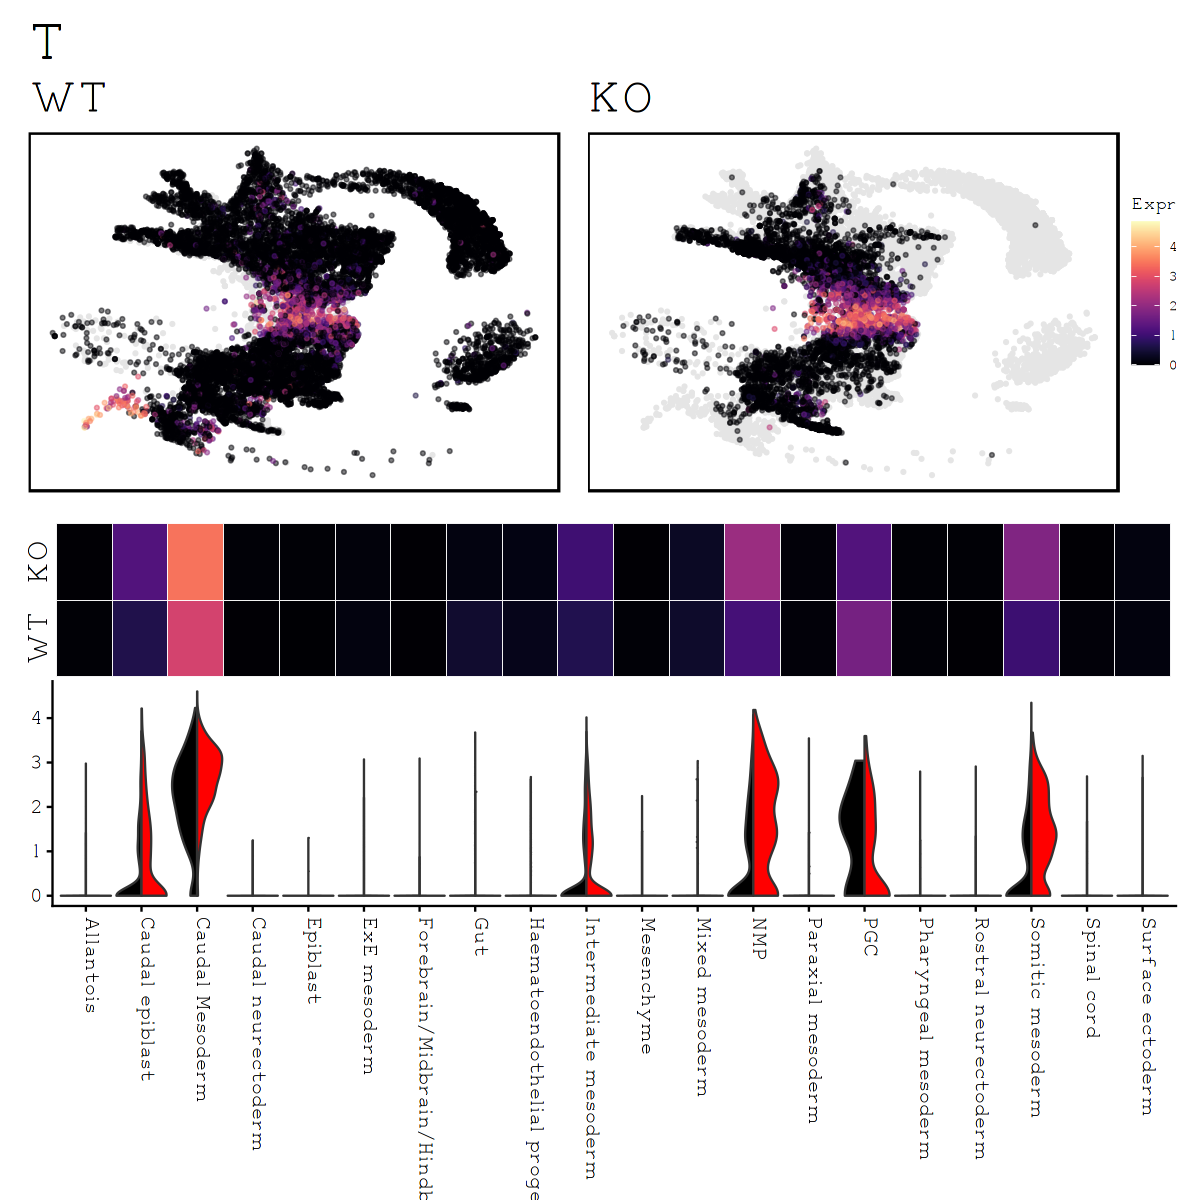

In [35]:
options(repr.plot.width=10, repr.plot.height=10)
plot_gene('T')

In [ ]:
P4ha2

# EdgeR Alsu's method

In [76]:
gg_volcano_plot <- function(to.plot, top_genes=10, xlim=NULL, ylim=NULL, label_groups = NULL) {
  
  negative_hits <- to.plot[sig==TRUE & logFC<0,gene]
  positive_hits <- to.plot[sig==TRUE & logFC>0,gene]
  all <- nrow(to.plot)
  
  # if (is.null(xlim))
  #   xlim <- max(abs(to.plot$logFC), na.rm=T)
  # if (is.null(ylim))
  #   ylim <- max(-log10(to.plot$padj_fdr+1e-100), na.rm=T)
  
  to.plot <- to.plot[!is.na(logFC) & !is.na(padj_fdr)] %>% .[order(-abs(logFC))]
  
  p <- ggplot(to.plot, aes(x=logFC, y=-log10(padj_fdr+1e-100))) +
    labs(x="Log fold change", y=expression(paste("-log"[10],"(q.value)"))) +
    ggrastr::geom_point_rast(aes(color=sig, size=sig)) +
    # geom_hline(yintercept = -log10(opts$threshold_fdr), color="blue") +
    geom_segment(aes(x=0, xend=0, y=0, yend=20), color="orange", size=0.5) +
    scale_color_manual(values=c("black","red")) +
    scale_size_manual(values=c(0.5,1)) +
    scale_x_continuous(limits=c(-6,6)) +
    scale_y_continuous(limits=c(0,22)) +
    annotate("text", x=0, y=20, size=4, label=sprintf("(%d)", all)) +
    annotate("text", x=-5, y=20, size=4, label=sprintf("%d (-)",length(negative_hits))) +
    annotate("text", x=5, y=20, size=4, label=sprintf("%d (+)",length(positive_hits))) +
    ggrepel::geom_text_repel(data=head(to.plot[sig==T],n=top_genes), aes(x=logFC, y=-log10(padj_fdr+1e-100), label=gene), max.overlaps=Inf, size=4) +
    theme_classic() +
    theme(
      axis.text = element_text(size=rel(0.75), color='black'),
      axis.title = element_text(size=rel(1.0), color='black'),
      legend.position="none"
    )
  
  
  if (length(label_groups)>0) {
    p <- p +
      annotate("text", x=-4, y=0, size=4, label=sprintf("Up in %s",label_groups[2])) +
      annotate("text", x=4, y=0, size=4, label=sprintf("Up in %s",label_groups[1]))
  }
  
  return(p)
}

In [26]:
meta_sce = meta %>% tibble::column_to_rownames("cell") %>% DataFrame

In [28]:
colData(sce) = meta_sce

In [33]:
colnames(colData(sce))

[1] "barcode"         "stage"           "batch"           "Sample_name"    
 [5] "batch_name"      "tdTom"           "index"           "sample"         
 [9] "doub.density"    "doublet"         "stripped"        "umap_1"         
[13] "umap_2"          "louvain_cluster" "celltype.mapped" "stage.mapped"   
[17] "closest.cell"    "celltype.score"  "cellstage.score" "umapX.mapped"   
[21] "umapY.mapped"

In [70]:
get_de_genes_bulk = function(sce , celltype){
  require(tibble)
  require(edgeR)
  sce = sce[ , sce$celltype.mapped == celltype]
  summed = summarizeAssayByGroup(counts(sce), colData(sce)[,c("sample","tdTom")])
  y <- DGEList(assay(summed, "sum"), samples=colData(summed), lib.size = colSums(assay(summed , "sum")))
  # select genes
  keep <- filterByExpr(y, group=summed$sample , min.count = 2 , min.total.count = 4)
  y <- y[keep,]
  # add offsets 
  y <- calcNormFactors(y)
  design <- model.matrix(~ factor(tdTom), y$samples)
  y <- estimateDisp(y, design)
  fit <- glmQLFit(y, design, robust=TRUE)
  res <- glmQLFTest(fit, coef=ncol(design))
  out = topTags(res, n = Inf )
  out = as.data.table(out, keep.rownames=T)%>%
    setnames(c("gene","logFC","logCPM","F","p.value","padj_fdr",  "adjust.method", "comparison", "test")) %>% 
                .[, sig := (padj_fdr<=0.01 & abs(logFC)>=1)] %>%
                .[is.na(sig),sig:=FALSE] %>% 
                setorder(-sig, padj_fdr, na.last=T)
  return(out)
}  

In [57]:
celltype = 'Mixed mesoderm'

In [55]:
colnames(colData(sce))

[1] "barcode"         "stage"           "batch"           "Sample_name"    
 [5] "batch_name"      "tdTom"           "index"           "sample"         
 [9] "doub.density"    "doublet"         "stripped"        "umap_1"         
[13] "umap_2"          "louvain_cluster" "celltype.mapped" "stage.mapped"   
[17] "closest.cell"    "celltype.score"  "cellstage.score" "umapX.mapped"   
[21] "umapY.mapped"

Warning message:
“Removed 13 rows containing missing values (geom_point).”
Warning message:
“Removed 7 rows containing missing values (geom_text_repel).”


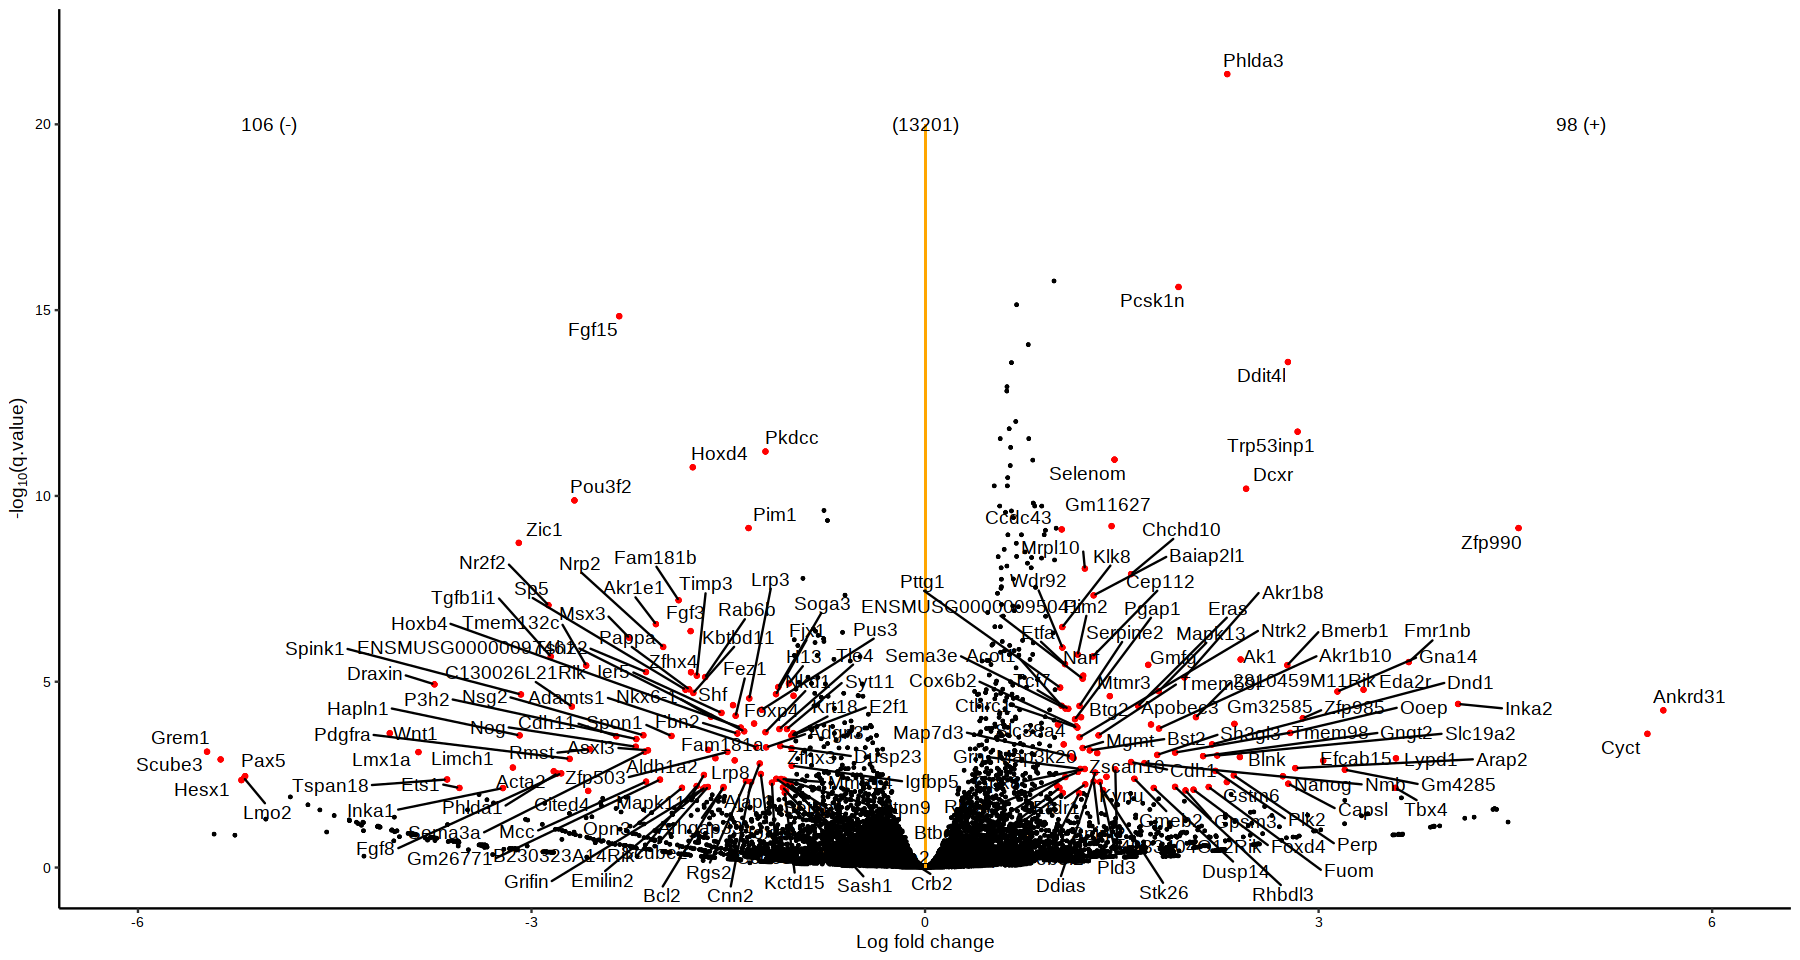

In [94]:
test = get_de_genes_bulk(sce, 'Spinal cord')

gg_volcano_plot(test, top_genes=200)

Warning message:
“Removed 16 rows containing missing values (geom_point).”
Warning message:
“Removed 11 rows containing missing values (geom_text_repel).”


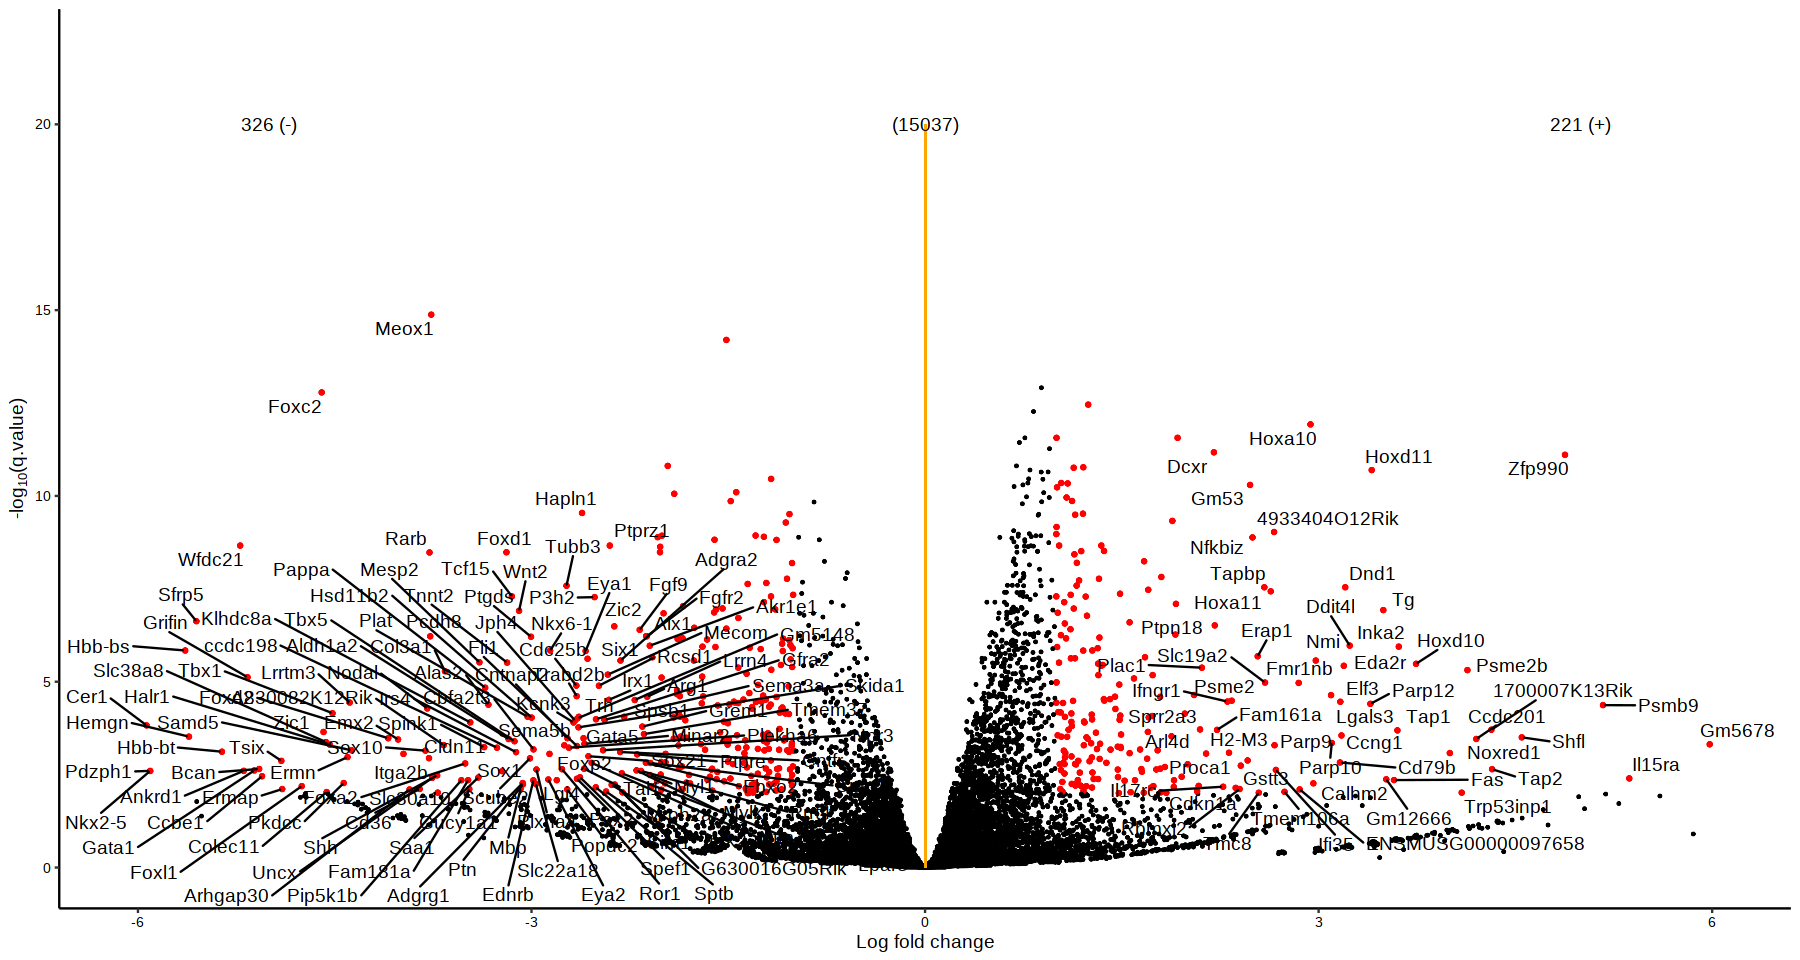

In [78]:
#exclude genes
xist = "ENSMUSG00000086503"
ychr = read.table("/rds/project/rds-SDzz0CATGms/users/bt392/software/ygenes.tab", stringsAsFactors = FALSE)[,1]
other = c("tomato-td") #for the chimera

exl_names = genenames[genenames$gene %in% c(ychr, xist, other)]$gene_name

In [85]:
length(exl_names)

[1] 735

In [79]:
WT_inj = read.csv('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/WT_injection/old/tomato_DEGs_edgeR.csv')

Warning message:
“Removed 10 rows containing missing values (geom_point).”
Warning message:
“Removed 6 rows containing missing values (geom_text_repel).”


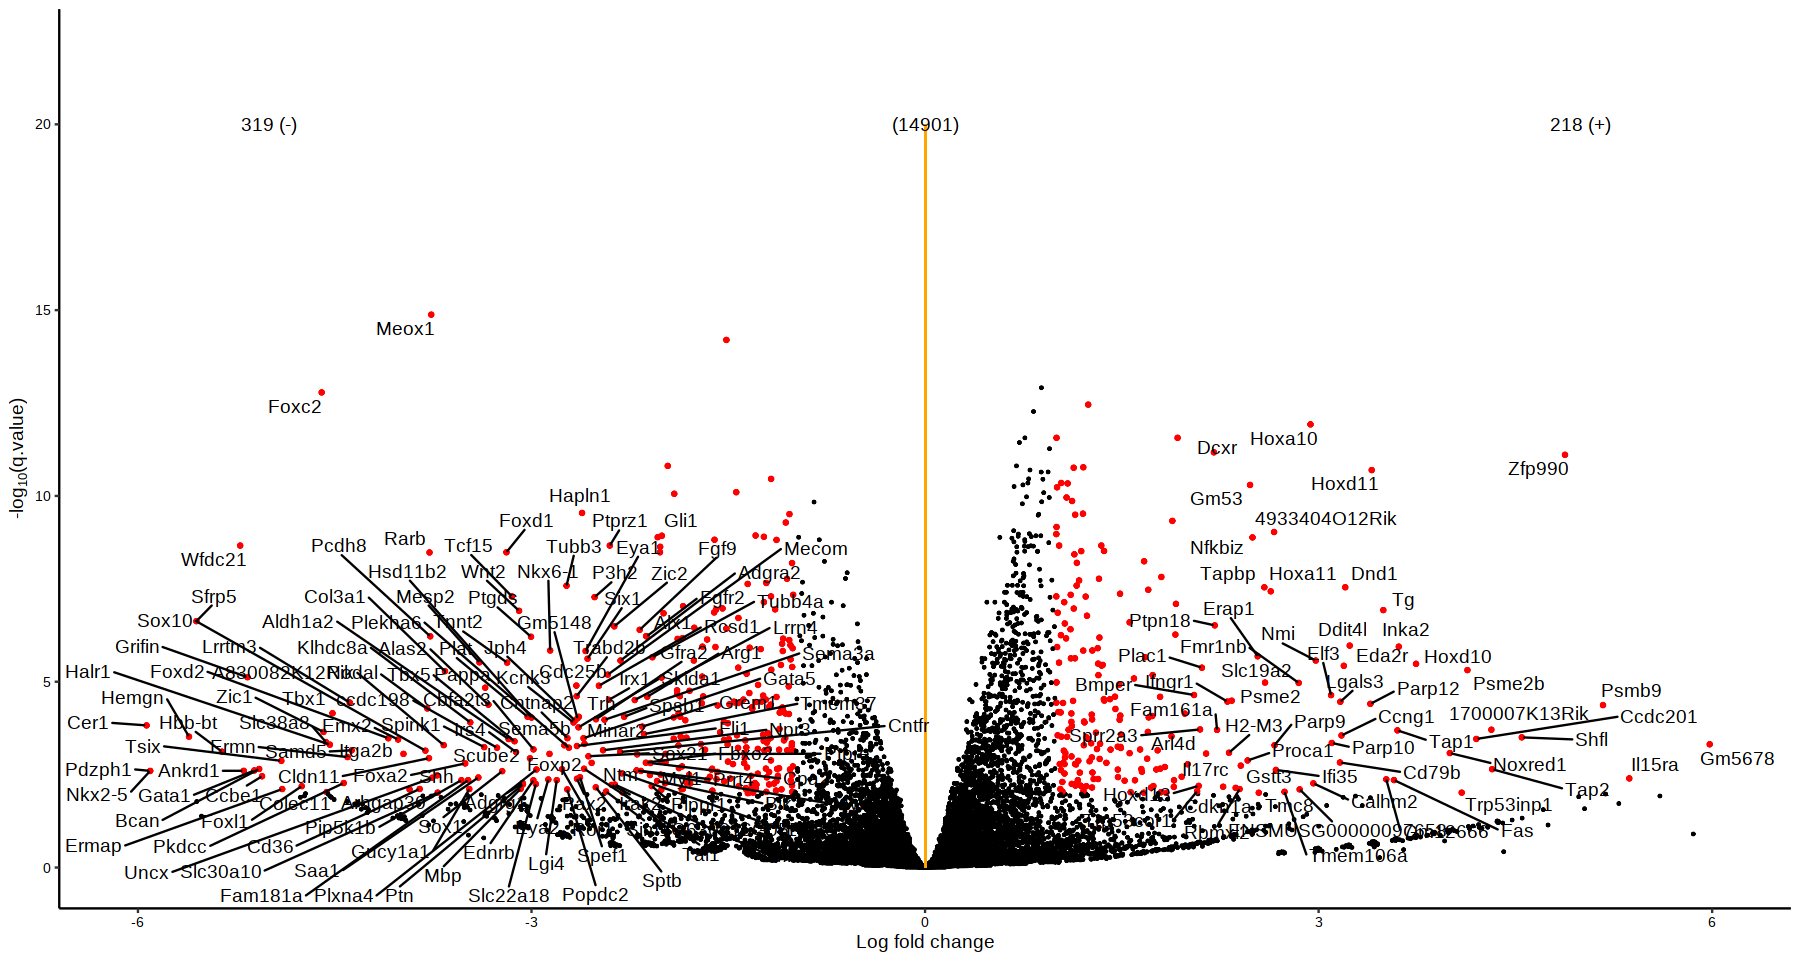

In [83]:
gg_volcano_plot(Intermediate_mesoderm, top_genes=200)

In [66]:
head(Intermediate_mesoderm)

table.rn,table.logFC,table.logCPM,table.F,table.PValue,table.FDR,adjust.method,comparison,test
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
tomato-td,10.3651122,4.375157,443.5453,6.987638e-20,1.050731e-15,BH,factor(tdTom)positive,glm
Meox1,-3.7643055,3.369116,333.2132,1.759155e-19,1.322620e-15,BH,factor(tdTom)positive,glm
Cd24a,-1.5144501,6.649753,294.1615,1.262041e-18,6.325773e-15,BH,factor(tdTom)positive,glm
Rpl26,0.8868745,12.086548,238.5796,3.262774e-17,1.226559e-13,BH,factor(tdTom)positive,glm
Foxc2,-4.5994907,2.512035,230.7313,5.444684e-17,1.637434e-13,BH,factor(tdTom)positive,glm
Psme1,1.2435995,7.271793,216.9418,1.390532e-16,3.484906e-13,BH,factor(tdTom)positive,glm


In [57]:
celltype = 'Mixed mesoderm'

In [55]:
colnames(colData(sce))

[1] "barcode"         "stage"           "batch"           "Sample_name"    
 [5] "batch_name"      "tdTom"           "index"           "sample"         
 [9] "doub.density"    "doublet"         "stripped"        "umap_1"         
[13] "umap_2"          "louvain_cluster" "celltype.mapped" "stage.mapped"   
[17] "closest.cell"    "celltype.score"  "cellstage.score" "umapX.mapped"   
[21] "umapY.mapped"

Warning message:
“Removed 13 rows containing missing values (geom_point).”
Warning message:
“Removed 7 rows containing missing values (geom_text_repel).”


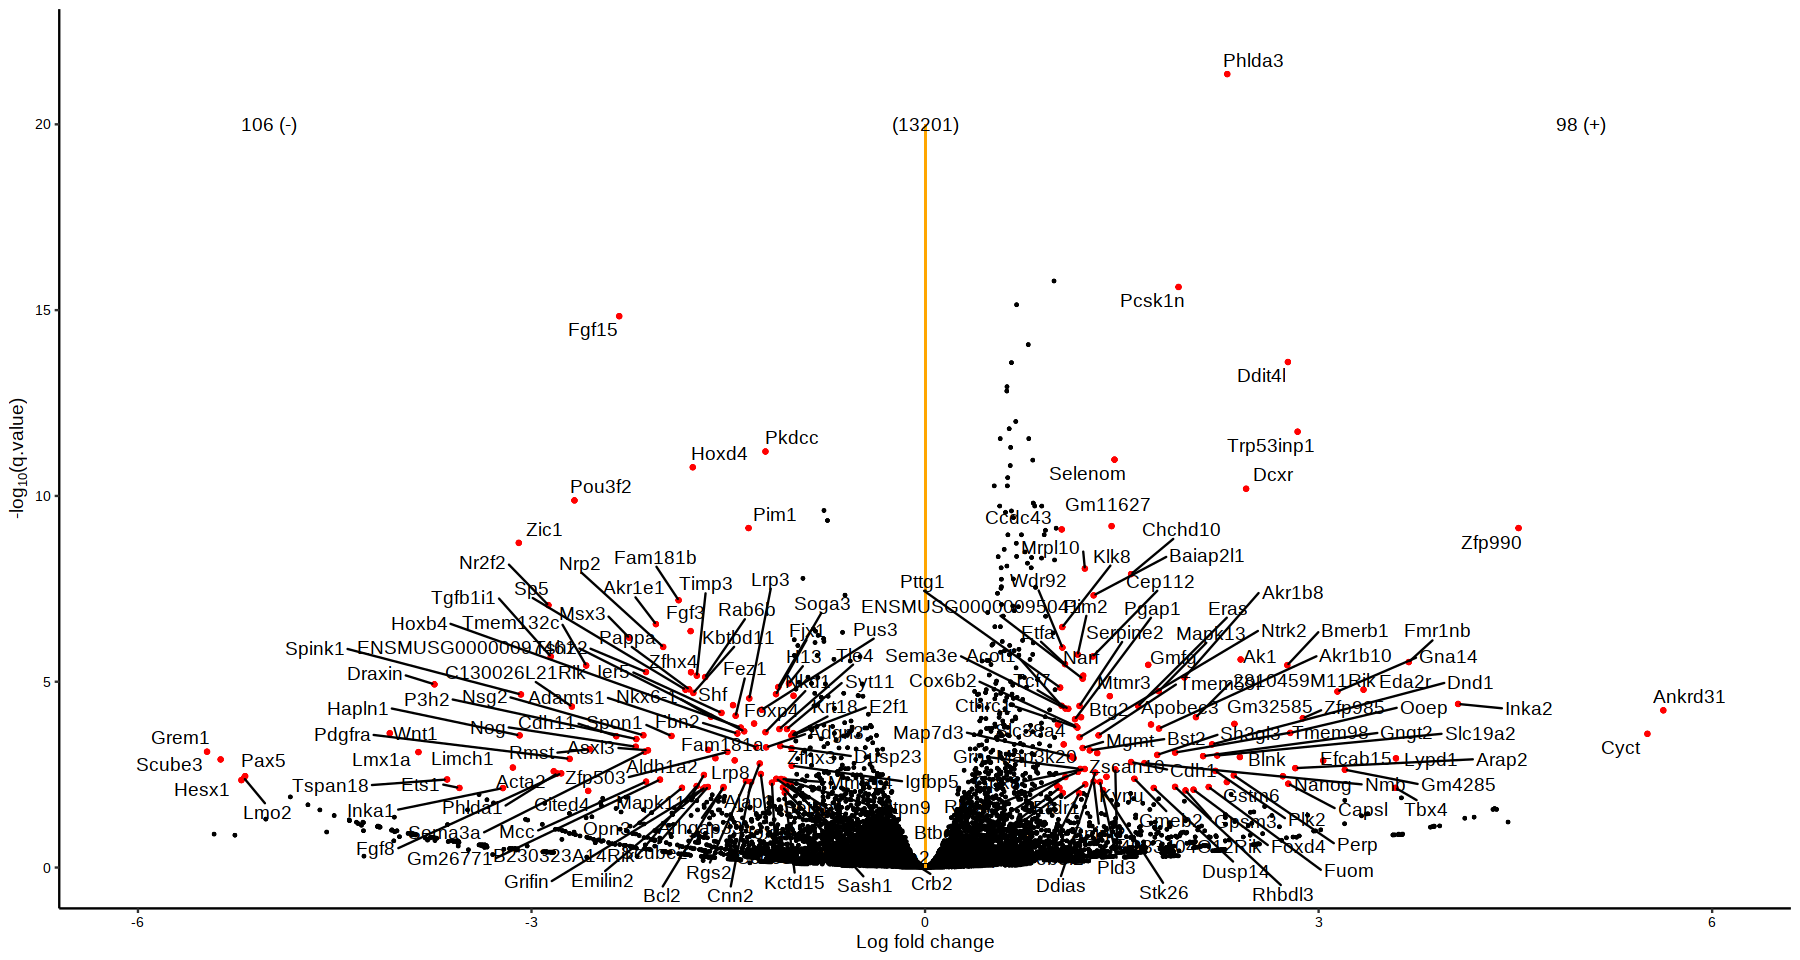

In [94]:
test = get_de_genes_bulk(sce, 'Spinal cord')

gg_volcano_plot(test, top_genes=200)

Warning message:
“Removed 11 rows containing missing values (geom_point).”
Warning message:
“Removed 6 rows containing missing values (geom_text_repel).”


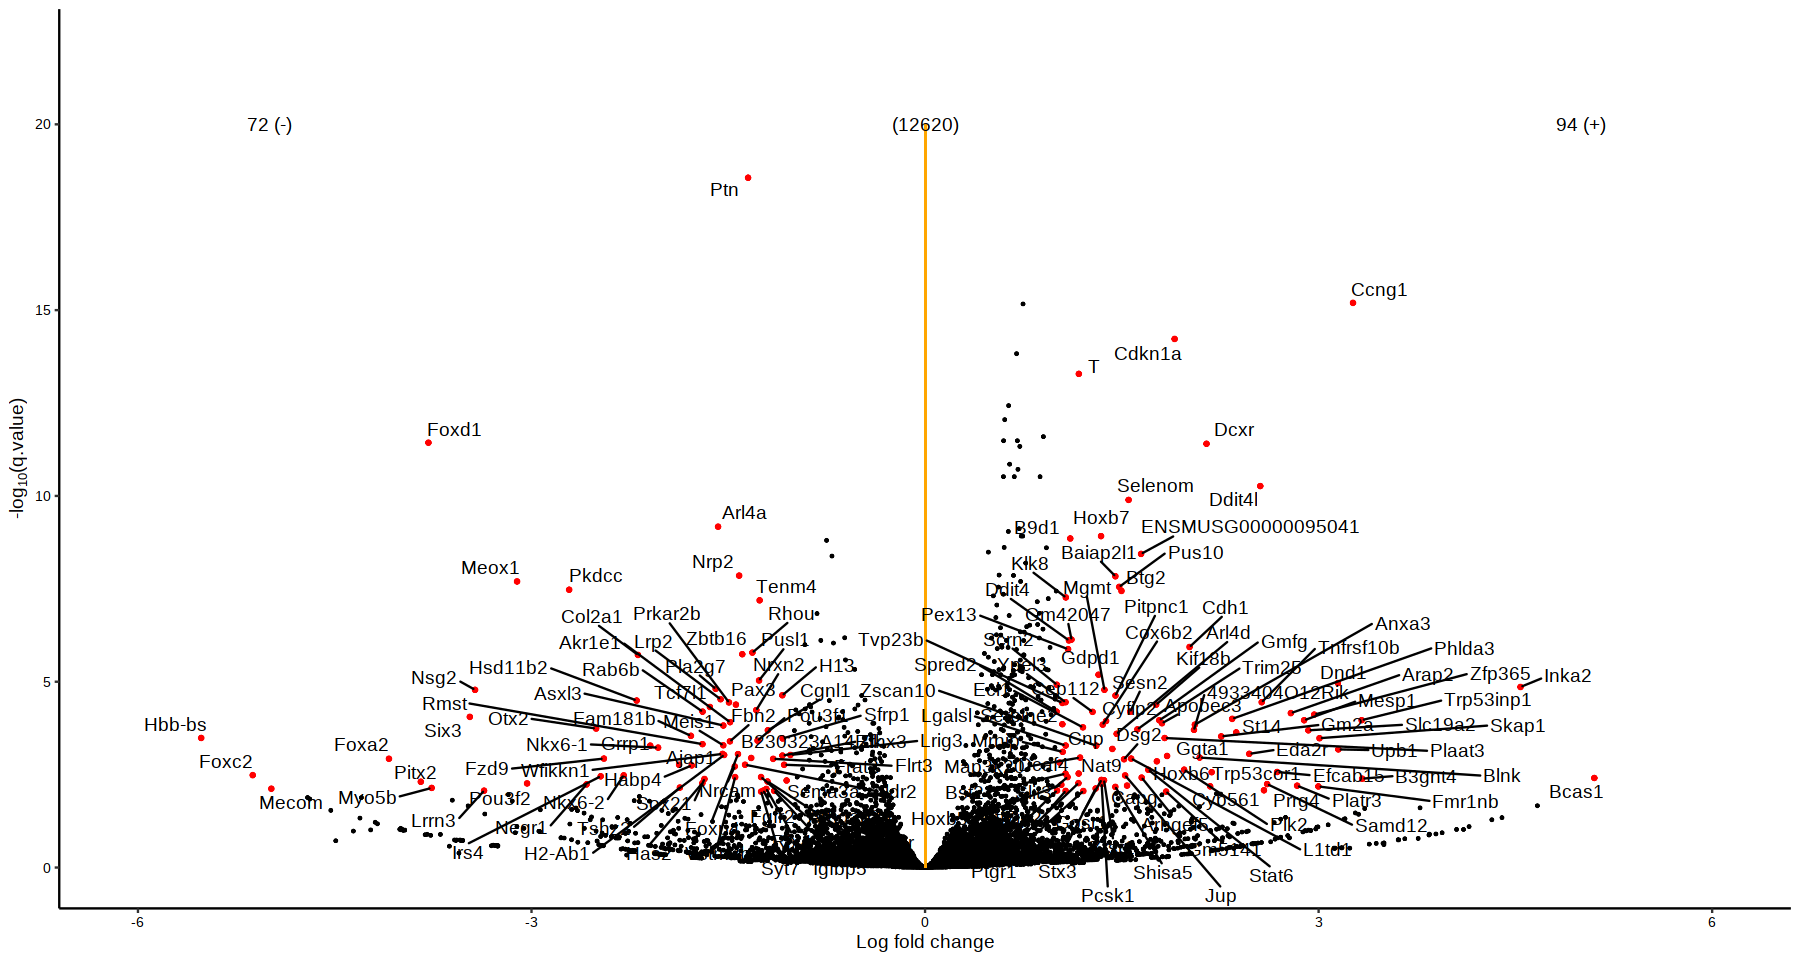

In [95]:
test = get_de_genes_bulk(sce, 'NMP')

gg_volcano_plot(test, top_genes=200)

Warning message:
“Removed 9 rows containing missing values (geom_point).”
Warning message:
“Removed 6 rows containing missing values (geom_text_repel).”


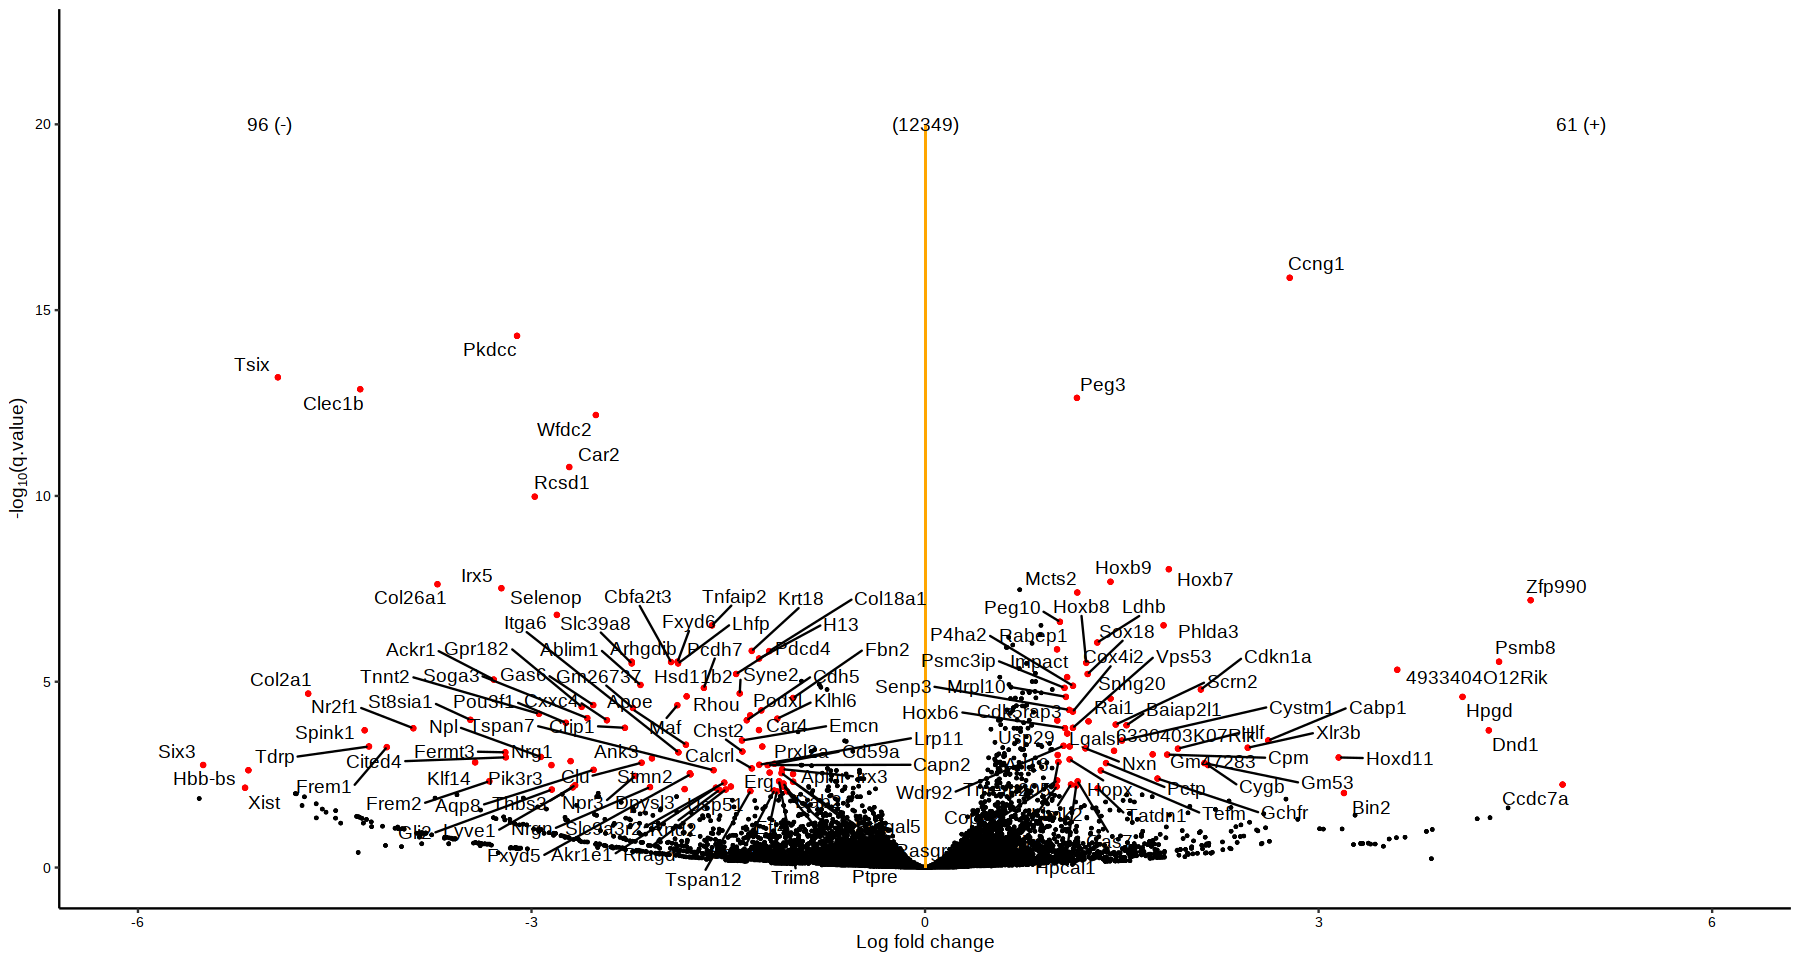

In [96]:
test = get_de_genes_bulk(sce, 'Haematoendothelial progenitors')

gg_volcano_plot(test, top_genes=200)

Warning message:
“Removed 9 rows containing missing values (geom_point).”
Warning message:
“Removed 6 rows containing missing values (geom_text_repel).”


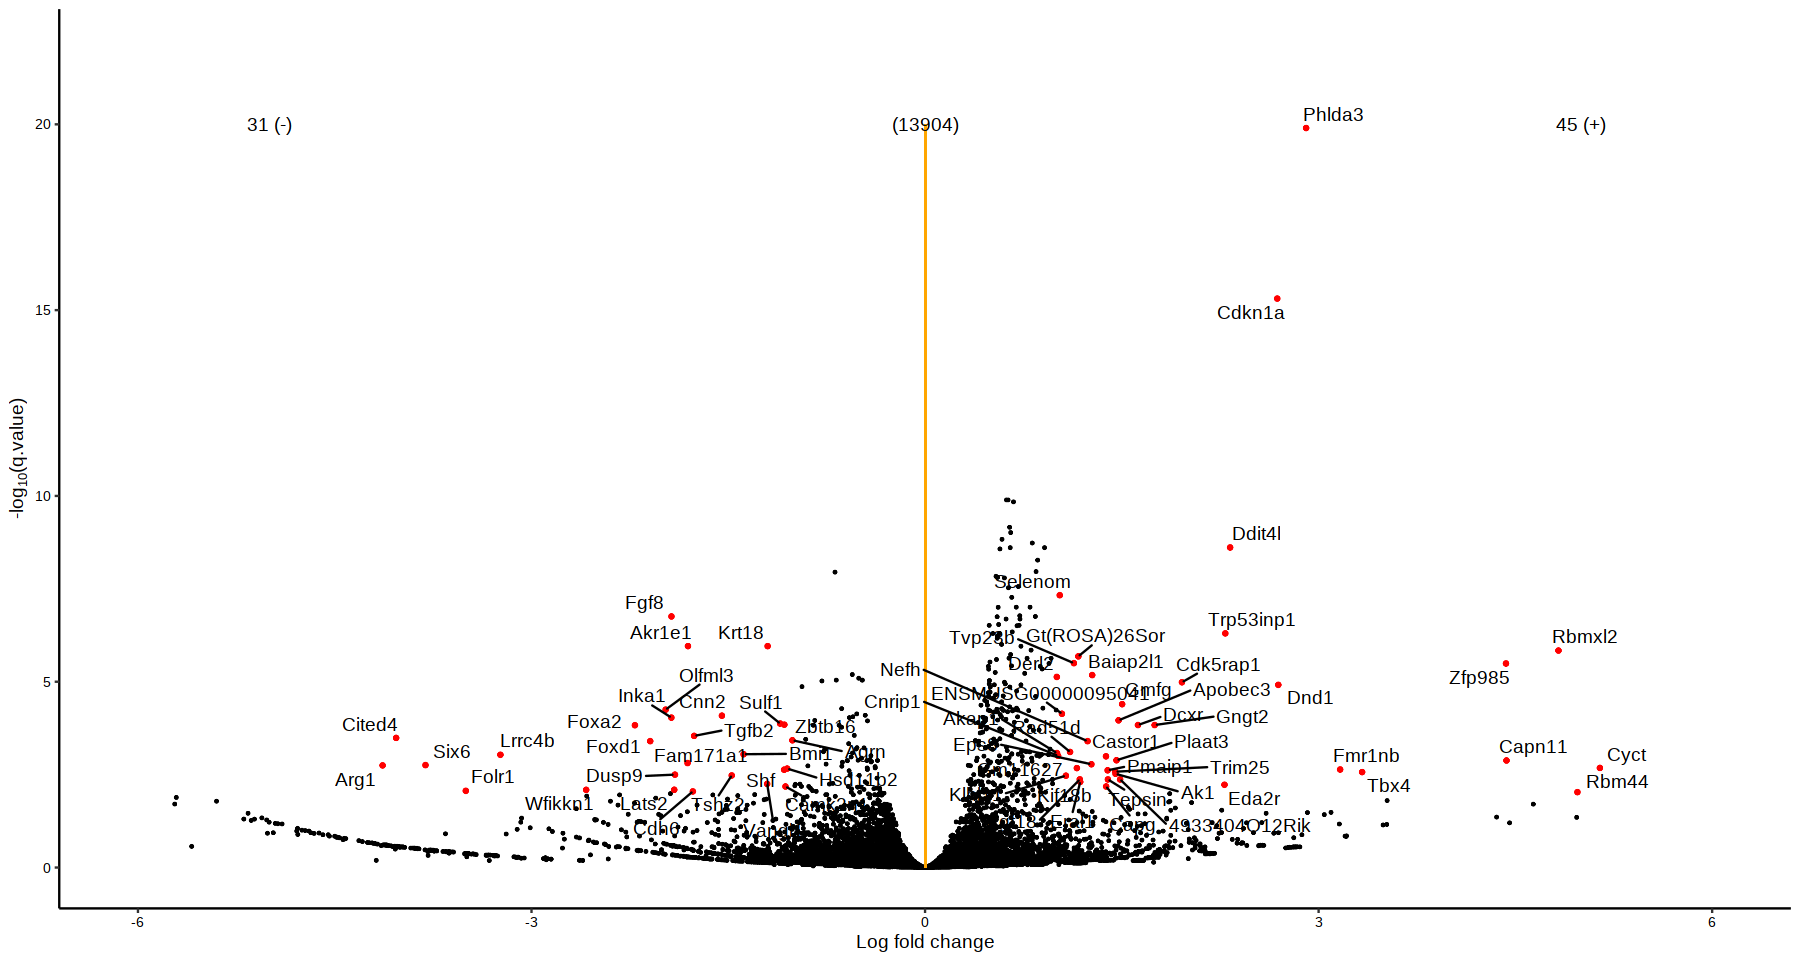

In [97]:
test = get_de_genes_bulk(sce, 'Forebrain/Midbrain/Hindbrain')

gg_volcano_plot(test, top_genes=200)

Warning message:
“Removed 21 rows containing missing values (geom_point).”
Warning message:
“Removed 11 rows containing missing values (geom_text_repel).”


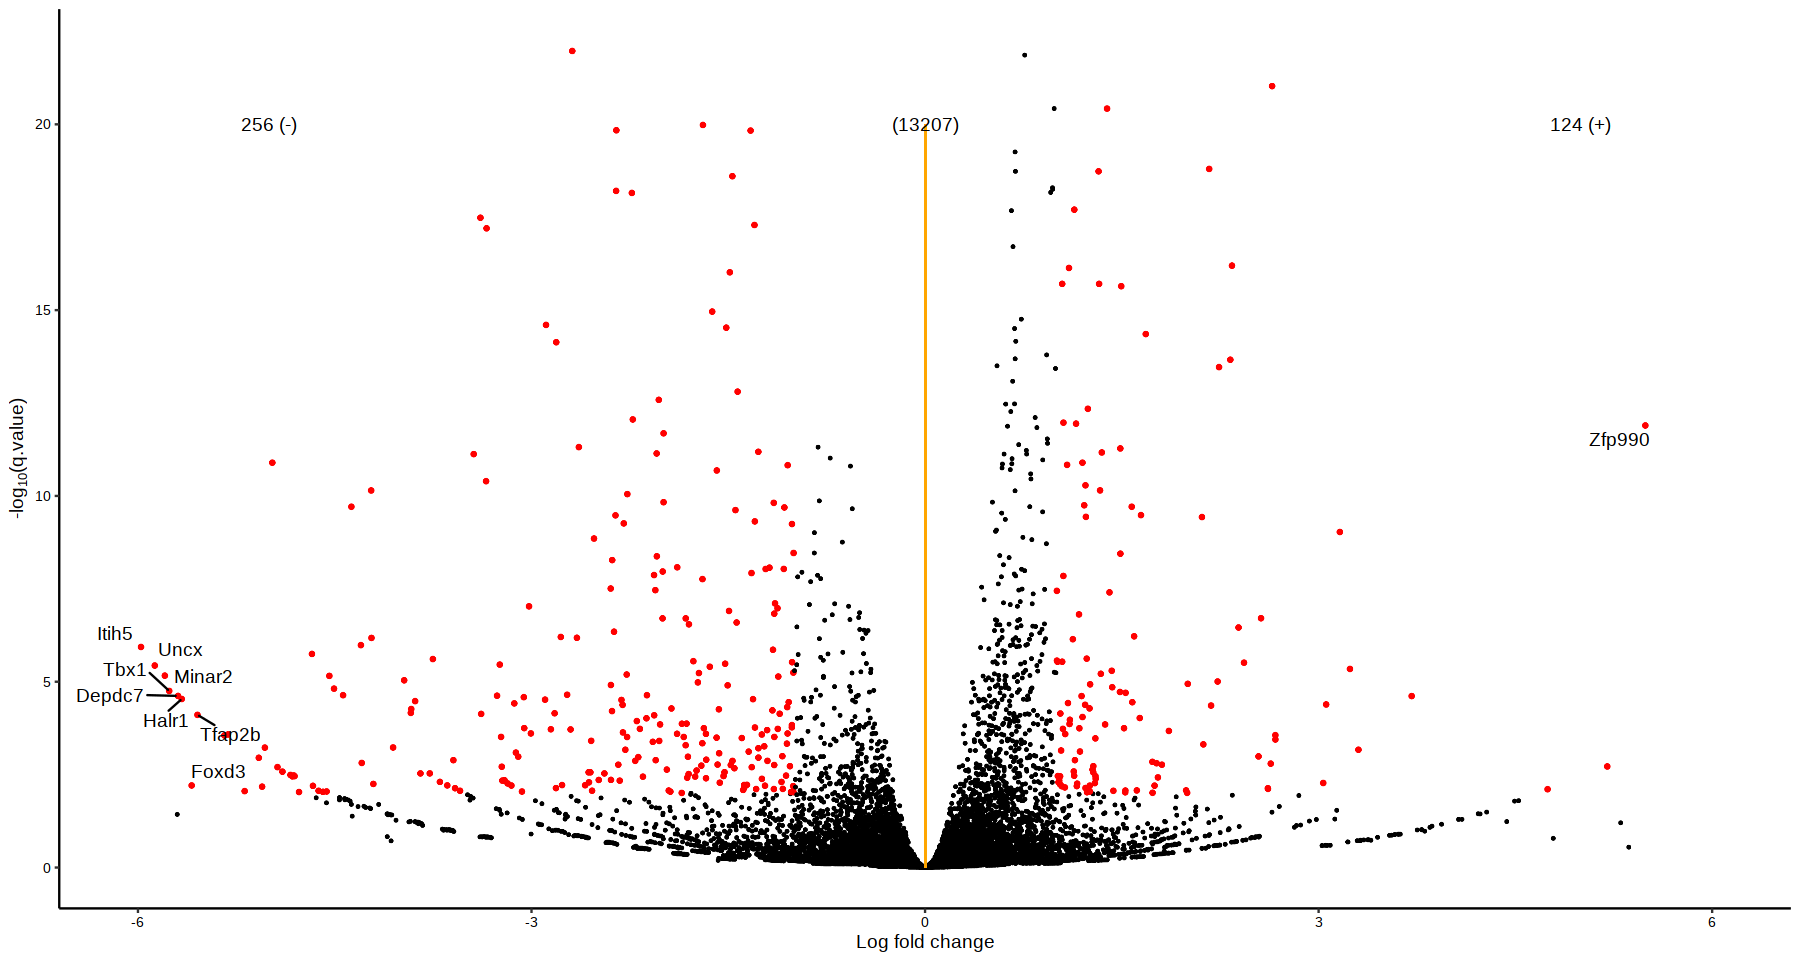

In [99]:
test = get_de_genes_bulk(sce, 'Somitic mesoderm')

gg_volcano_plot(test, top_genes=20)